# 🌱 PlantVillage Pathology Benchmarking & Explainable AI Pipeline

An end-to-end, academically rigorous machine learning pipeline designed to classify agricultural leaf diseases using the PlantVillage dataset. This project goes beyond standard accuracy metrics by systematically profiling state-of-the-art Transfer Learning architectures against a custom baseline, evaluating hardware inference speed for edge deployment, and utilizing Gradient-weighted Class Activation Mapping (Grad-CAM) to prove model interpretability.


## 🎯 Project Overview
In agricultural machine learning, deploying a model to a mobile edge device (like a farmer's smartphone) requires balancing predictive power with hardware efficiency. Furthermore, biological datasets are inherently imbalanced and prone to data leakage.

This pipeline was engineered to solve these challenges through:
1. **Strict Data Leakage Prevention:** Physically quarantining validation data *before* any augmentation occurs.
2. **Hybrid Class Balancing:** Curing the "Accuracy Paradox" by programmatically downsampling majority classes and augmenting minority classes (via OpenCV) to achieve a perfectly uniform training distribution.
3. **Holistic Evaluation:** Using Macro F1-Scores to measure true predictive power across 39 classes, while explicitly measuring GPU inference latency (`ms/img`) and disk footprint (`MB`).
4. **Visual Interpretability:** Automating batch Grad-CAM generation to prove the models are learning true pathological lesions rather than overfitting to background artifacts (combating the *Clever Hans* effect).

---

## ⚙️ Pipeline Architecture

The codebase is structured sequentially to ensure idempotency and reproducibility:

### Phase 1: Data Engineering
* **Native Acquisition:** Secure, idempotent download of the ~800MB Mendeley dataset using native Python `urllib`.
* **Exploratory Data Analysis (EDA):** Automated directory mapping and severe class-imbalance detection.
* **Leak-Proof Quarantine:** A strict 80/20 train/validation physical directory split.
* **Hybrid Balancing Engine:** Forces the training set to exactly `800` images per class. Uses `cv2` for dynamic Gamma correction, Gaussian Noise, HSV color shifting, rotation, and Histogram Equalization.

### Phase 2: Model Training
* **Custom Baseline:** A scratch-built, 9-layer Convolutional Neural Network ($224 \times 224$ input, 50,176-dimensional flattened vector) to establish a benchmark control metric.
* **Transfer Learning Engine:** A dynamic training loop that freezes the base ImageNet weights of standard architectures, dynamically swaps the classification head for 39 classes, and fine-tunes the top ~20% of the network.

### Phase 3: Post-Training Evaluation
* **Sklearn Integration:** Aggregates all validation predictions to calculate strictly Macro-Averaged Precision, Recall, and F1-Scores.
* **Latency Profiling:** Uses `torch.cuda.Event(enable_timing=True)` for hardware-synchronized, millisecond-accurate inference profiling.

### Phase 4: Explainable AI (XAI)
* **Grad-CAM Auditing:** Hooks into the final convolutional layer of the trained networks to visualize the gradient impact of spatial features. Automatically samples 50 random validation images and generates side-by-side diagnostic plots.

---

## 🧠 Model Zoo & Benchmarking
The benchmarking engine currently evaluates the following architectures:

1. **Custom 9-Layer CNN** (Control Baseline)
2. **EfficientNet-B0** (Compound Scaling Baseline | $224 \times 224$)
3. **EfficientNet-B1** (Scaled Resolution/Depth | $240 \times 240$)
4. **EfficientNet-B2** (Scaled Resolution/Depth | $260 \times 260$)
5. **MobileNetV3-Large** (Hardware-Aware NAS edge-optimization | $224 \times 224$)
6. **ResNet34** (Legacy Residual Paradigm | $224 \times 224$)


# Setup

In [5]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu130
!pip install torchsummary opencv-python numpy pandas matplotlib seaborn grad-cam scikit-learn


Looking in indexes: https://download.pytorch.org/whl/cu130


In [ ]:
import torch

# Check if CUDA (GPU support) is available
print(f"Is CUDA available? {torch.cuda.is_available()}")

# Get the name of the exact GPU you are using
if torch.cuda.is_available():
    print(f"Current device name: {torch.cuda.get_device_name(0)}")
else:
    print("PyTorch is using the CPU.")


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision import datasets
from torchvision.datasets import ImageFolder
import torch.optim as optim
from torch.utils.data.sampler import SubsetRandomSampler
from torch.utils.data import DataLoader
import torch.utils.data as data_utils
from torch.utils.data import random_split
import torch.nn.functional as F
from torchsummary import summary
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import os
import random
import glob
import urllib.request
import zipfile
import shutil
from pathlib import Path
import gc
from sklearn.metrics import precision_recall_fscore_support, classification_report
from datetime import datetime
import time


# Dataprep

In [ ]:

base_dir = 'D:/AIDL/PlantVillage_Project'
zip_path = os.path.join(base_dir, 'plantvillage_dataset.zip')
split_dir = os.path.join(base_dir, 'split_dataset')
train_dir = os.path.join(split_dir, 'train')
val_dir = os.path.join(split_dir, 'val')

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


### **Dataset Acquisition & Directory Initialization**

#### **Objective & Context**
The objective of this code block is to establish the foundational directory structure for a project and securely download a remote dataset. It implements idempotency—meaning the code can be executed multiple times without causing redundant operations or errors—and uses native Python libraries to ensure the script functions seamlessly across any operating system.

#### **Deep Dive: Code Mechanics**
* **`os.makedirs(base_dir, exist_ok=True)`:** * This function attempts to create the directory specified by the `base_dir` variable. The `exist_ok=True` argument is a crucial safety mechanism; it tells Python to silently ignore the command if the folder already exists, preventing a script-crashing `FileExistsError`.
* **`os.path.join(base_dir, 'plantvillage_dataset.zip')`:** * Rather than hardcoding string concatenations (e.g., `base_dir + "/filename.zip"`), `os.path.join` dynamically constructs the file path using the correct directory separator for the host operating system (e.g., `\` for Windows, `/` for Linux/macOS).
* **`dataset_url`:** * Stores the target URL pointing to the Mendeley data repository.
* **The Idempotency Check (`if not os.path.exists(zip_path):`)**: 
  * Before initiating a heavy network request, the `os.path.exists()` function checks the local file system. If the zip file is already present at the target path, the conditional skips the download block and proceeds to the `else` statement.
* **`urllib.request.urlretrieve(dataset_url, zip_path)`:** * This is a native Python networking function. It opens a connection to the specified `dataset_url`, streams the byte data over the network, and writes it directly to the local disk at the location defined by `zip_path`.

#### **Machine Learning Theory: Workflow Efficiency & Portability**
* **I/O Bottleneck Prevention:** Machine learning engineering requires rapid iteration, which often involves repeatedly restarting the kernel and running scripts from the top. Wrapping heavy data downloads in a conditional existence check ensures that network bandwidth and disk writing times are only consumed exactly once, eliminating a massive bottleneck in the development cycle.
* **OS-Agnostic Execution:** By relying on standard library modules like `os` and `urllib.request`, this pipeline avoids OS-specific shell commands (such as Linux `wget` or `curl`). This guarantees the code is highly portable and can run on any machine—whether a local Windows workstation, a macOS laptop, or a Linux-based cloud server—without modification.

#### **Data & State Flow**
* **Inputs:** A predefined base directory path (`base_dir`) and a remote URL (`dataset_url`).
* **Outputs (Artifacts):** 
  1. The creation of the base directory on the local disk (if it did not already exist).
  2. The `plantvillage_dataset.zip` archive securely saved to that directory.

In [ ]:

# Define the base folder in your local working directory
os.makedirs(base_dir, exist_ok=True)

# Define paths and URL
zip_path = os.path.join(base_dir, 'plantvillage_dataset.zip')
dataset_url = "https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/d5652a28-c1d8-4b76-97f3-72fb80f94efc/file_downloaded"

# Download the file using Python's native library
if not os.path.exists(zip_path):
    print("Downloading PlantVillage dataset locally... (This might take a few minutes)")
    urllib.request.urlretrieve(dataset_url, zip_path)
    print("Download complete!")
else:
    print("Dataset zip already exists. Skipping download.")


Dataset zip already exists. Skipping download.


### **Dataset Extraction & Class Distribution Analysis**

#### **Objective & Context**
The objective of this code block is to safely unpack a compressed dataset archive, dynamically locate the underlying directory structure containing the data, and perform an initial Exploratory Data Analysis (EDA). Specifically, it maps out the distribution of images across all categories. It incorporates defensive programming techniques to prevent redundant extractions and to filter out invalid file types.

#### **Deep Dive: Code Mechanics**
* **Idempotent Extraction (`if not os.path.exists(...) or not os.listdir(...)`):**
  * The script defines `extract_dir` and performs a "smart check." It verifies not only if the directory exists, but also if it is empty. If files are already present, it entirely bypasses the `zipfile` extraction block. This prevents the script from unnecessarily consuming time and disk I/O to unpack the archive on subsequent runs.
* **Context Management (`with zipfile.ZipFile(zip_path, 'r') as zip_ref:`):**
  * The `with` statement creates a context manager. This ensures that the file stream to the `.zip` archive is automatically and safely closed the moment `extractall()` finishes, preventing memory leaks and locked files within the operating system.
* **Dynamic Root Discovery (`os.walk`):**
  * Compressed datasets often extract into unpredictable, nested folder structures (e.g., `extracted_data/Dataset/classes/...`). Instead of hardcoding a brittle file path, `os.walk` recursively traverses the directory tree. 
  * The heuristic `if len(dirs) > 10:` assumes that the directory containing a large number of subdirectories (the individual classes) is the true target root. Once found, it breaks the loop and sets the `dataset_root` variable.
* **Safe Image Filtering (`glob.glob` & List Comprehension):**
  * The script iterates through each identified class directory. While `glob.glob('*.*')` fetches all files, operating systems frequently auto-generate hidden, non-image metadata files (like `.DS_Store` on macOS or `Thumbs.db` on Windows) inside these folders.
  * The list comprehension `img.lower().endswith(('.png', '.jpg', '.jpeg'))` acts as a strict programmatic filter, ensuring only valid image extensions are appended to the final list.
* **Aggregation (`class_counts` & `sum`):**
  * The length of the filtered image list is assigned to the `class_counts` dictionary using the directory name as the key. Finally, the dictionary is sorted, printed to the terminal, and summed to calculate the absolute total of valid images.

#### **Machine Learning Theory: Diagnostic EDA & Class Imbalance**
* **I/O Optimization:** In data engineering, extracting large archives is a heavily I/O-bound operation. Implementing conditional checks to skip this step on consecutive executions is a foundational practice for accelerating the iterative machine learning development cycle.
* **Quantifying Class Imbalance:** The core theoretical purpose of the counting loop is to audit the dataset for **Class Imbalance**. In biological or real-world datasets, categories are rarely uniform. By explicitly printing the integer count for every class, the engineer can diagnose whether a future neural network will be biased toward a majority class—a phenomenon known as the Accuracy Paradox—allowing them to plan necessary data augmentation or downsampling strategies before training begins.

#### **Data & State Flow**
* **Inputs:** Implicitly relies on previously defined variables: `base_dir` and `zip_path`.
* **Outputs (Artifacts):** 
  1. The physical extraction of files to the `extracted_data` folder on the local disk.
  2. The `dataset_root` string variable, dynamically mapped to the correct directory containing the class folders.
  3. A populated `class_counts` dictionary mapping class names (strings) to their exact image counts (integers).
  4. Terminal outputs displaying the individual counts per class and the `total_original_images` integer.

In [ ]:

extract_dir = os.path.join(base_dir, 'extracted_data')

# Smart Check: Only unzip if the folder doesn't exist or is empty
if not os.path.exists(extract_dir) or not os.listdir(extract_dir):
    os.makedirs(extract_dir, exist_ok=True)
    print("Unzipping dataset locally... (This may take a moment)")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Unzipping complete!")
else:
    print("Dataset already extracted. Skipping unzip phase.")

# Locate the actual root folder containing the class directories
dataset_root = extract_dir
for root, dirs, files in os.walk(extract_dir):
    if len(dirs) > 10:
        dataset_root = root
        break

print(f"\nDataset root identified at: {dataset_root}")

# Count images per class
class_counts = {}
for class_name in os.listdir(dataset_root):
    class_dir = os.path.join(dataset_root, class_name)
    if os.path.isdir(class_dir):
        images = glob.glob(os.path.join(class_dir, '*.*'))
        images = [img for img in images if img.lower().endswith(
            ('.png', '.jpg', '.jpeg'))]
        if len(images) > 0:
            class_counts[class_name] = len(images)

print("\n--- Image Counts per Class ---")
for cls, count in sorted(class_counts.items()):
    print(f"{cls}: {count} images")

total_original_images = sum(class_counts.values())
print(f"\nTotal images before balancing: {total_original_images}")


Unzipping dataset locally... (This may take a moment)
Unzipping complete!

Dataset root identified at: D:/AIDL/PlantVillage_Project\extracted_data\Plant_leave_diseases_dataset_without_augmentation

--- Image Counts per Class ---
Apple___Apple_scab: 630 images
Apple___Black_rot: 621 images
Apple___Cedar_apple_rust: 275 images
Apple___healthy: 1645 images
Background_without_leaves: 1143 images
Blueberry___healthy: 1502 images
Cherry___Powdery_mildew: 1052 images
Cherry___healthy: 854 images
Corn___Cercospora_leaf_spot Gray_leaf_spot: 513 images
Corn___Common_rust: 1192 images
Corn___Northern_Leaf_Blight: 985 images
Corn___healthy: 1162 images
Grape___Black_rot: 1180 images
Grape___Esca_(Black_Measles): 1383 images
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1076 images
Grape___healthy: 423 images
Orange___Haunglongbing_(Citrus_greening): 5507 images
Peach___Bacterial_spot: 2297 images
Peach___healthy: 360 images
Pepper,_bell___Bacterial_spot: 997 images
Pepper,_bell___healthy: 1478 image

### **Data-Leak-Proof Split & Hybrid Balancing**

#### **Objective & Context**
The objective of this code block is to permanently isolate the validation data from the training data, define a suite of computer vision transformations, and enforce a strict uniform distribution of exactly 800 images per training class. This cell physically executes the prevention of data leakage and resolves the dataset's class imbalance using a hybrid downsampling and augmentation strategy.

#### **Deep Dive: Code Mechanics**
* **Strict Physical Split (`random.shuffle` & `shutil.copy`):**
  * The code establishes isolated `train` and `val` directories. It implements an idempotency check (`if not os.path.exists(split_dir):`) to prevent overwriting existing splits.
  * For each class, it grabs all valid images, randomizes their order using `random.shuffle()`, and calculates an exact 80% index cutoff. 
  * Array slicing (`[:split_idx]` and `[split_idx:]`) separates the data, and `shutil.copy` physically duplicates the files into their respective quarantine zones.
* **OpenCV Augmentation Suite:**
  * **`aug_flip`:** Randomly flips the image horizontally, vertically, or both (`[-1, 0, 1]`).
  * **`aug_gamma`:** Adjusts the image luminance using a non-linear Gamma curve and a Look-Up Table (`cv2.LUT`), simulating overexposed or underexposed lighting conditions.
  * **`aug_noise`:** Generates a Gaussian noise matrix (`np.random.normal`) and adds it to the image, clipping the values to remain within the valid 0-255 byte range.
  * **`aug_color`:** Converts the image from BGR to HSV color space, applies random integer shifts to the Saturation (S) and Value (V) channels, and converts it back, simulating different camera sensors or time-of-day lighting.
  * **`aug_rotate`:** Calculates a 2D rotation matrix around the image center and applies an affine warp (`cv2.warpAffine`) between -45 and 45 degrees.
  * **`aug_histogram`:** Converts the image to YUV space and applies histogram equalization strictly to the Y (luminance) channel, maximizing image contrast without corrupting the color balance.
* **Hybrid Balancing Engine (`TARGET_COUNT = 800`):**
  * The script maps the current counts of the *training* directory only.
  * **Downsampling:** If a class exceeds 800 images, `random.sample()` selects the exact excess amount, and `os.remove()` deletes them from the disk.
  * **Augmenting:** If a class is below 800 images, it enters a generation loop. It randomly selects an existing image, randomly selects 1 to 3 distinct augmentation functions, and applies them sequentially. It then constructs a highly descriptive filename tracing its augmentation history (e.g., `leaf_Flipped_Noise_1.jpg`) and saves it via `cv2.imwrite()`.

#### **Machine Learning Theory: Leakage & Variance**
* **The Golden Rule of Data Leakage:** This script intentionally performs the physical directory split *before* any augmentation occurs. If you augment an entire dataset first and *then* split it 80/20, a rotated copy of a leaf might end up in the training set while the original leaf ends up in the validation set. The neural network will simply memorize that specific leaf's spot patterns and artificially inflate its validation accuracy. Quarantining the validation set first ensures the model is tested on purely unseen, un-augmented real-world data.
* **Regularization via Augmentation:** Neural networks are prone to overfitting on minority classes because they see the exact same pixels too many times. By applying random rotations, noise, and color shifts, we artificially expand the visual variance of the dataset. This forces the convolutional filters to learn generalized pathological features (e.g., the texture of a blight lesion) rather than memorizing the orientation or background lighting of a specific photo.

#### **Data & State Flow**
* **Inputs:** Raw class folders located at `dataset_root`.
* **Outputs (Artifacts):** 
  1. A `split_dataset/val` directory containing exactly 20% of the original, un-augmented raw data (permanently quarantined).
  2. A `split_dataset/train` directory where every single class folder has been programmatically forced to contain exactly 800 images, achieving a perfect uniform distribution.

In [ ]:

# --- 1. Setup Directories & Physical Split ---
split_dir = os.path.join(base_dir, 'split_dataset')
train_dir = os.path.join(split_dir, 'train')
val_dir = os.path.join(split_dir, 'val')

# SMART CHECK: Only run the split if it hasn't been done yet
if not os.path.exists(split_dir):
    print("Starting strict 80/20 Train/Val physical split...")
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)

    # Physically Split the Raw Data
    for class_name in os.listdir(dataset_root):
        class_path = os.path.join(dataset_root, class_name)
        if not os.path.isdir(class_path):
            continue

        os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)

        images = glob.glob(os.path.join(class_path, '*.*'))
        images = [img for img in images if img.lower().endswith(
            ('.png', '.jpg', '.jpeg'))]

        # Shuffle for randomness, then split 80/20
        random.shuffle(images)
        split_idx = int(len(images) * 0.8)
        train_imgs = images[:split_idx]
        val_imgs = images[split_idx:]

        # Copy files to respective directories
        for img in train_imgs:
            shutil.copy(img, os.path.join(train_dir, class_name))
        for img in val_imgs:
            shutil.copy(img, os.path.join(val_dir, class_name))

    print("Physical split complete! Validation set is now quarantined.")
else:
    print("Physical split already exists. Skipping quarantine phase.")

# --- 2. Define Augmentation Techniques ---


def aug_flip(img):
    flip_type = random.choice([-1, 0, 1])
    return cv2.flip(img, flip_type), "Flipped"


def aug_gamma(img):
    gamma = random.uniform(0.5, 1.5)
    invGamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** invGamma) *
                     255 for i in np.arange(0, 256)]).astype("uint8")
    return cv2.LUT(img, table), f"Gamma{gamma:.1f}"


def aug_noise(img):
    row, col, ch = img.shape
    mean = 0
    sigma = 15
    gauss = np.random.normal(mean, sigma, (row, col, ch))
    noisy = np.clip(img + gauss, 0, 255).astype('uint8')
    return noisy, "Noise"


def aug_color(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    s = cv2.add(s, random.randint(-30, 30))
    v = cv2.add(v, random.randint(-30, 30))
    final_hsv = cv2.merge((h, s, v))
    return cv2.cvtColor(final_hsv, cv2.COLOR_HSV2BGR), "ColorAug"


def aug_rotate(img):
    angle = random.randint(-45, 45)
    h, w = img.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(img, M, (w, h)), f"Rot{angle}"


def aug_histogram(img):
    img_yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
    img_yuv[:, :, 0] = cv2.equalizeHist(img_yuv[:, :, 0])
    return cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR), "HistEq"


augmentations = [aug_flip, aug_gamma, aug_noise,
                 aug_color, aug_rotate, aug_histogram]

# --- 3. Hybrid Balancing Logic (ONLY ON TRAINING SET) ---
TARGET_COUNT = 800  # 80% of our original 1000 target

# Calculate new class counts just for the training directory
train_counts = {}
for class_name in os.listdir(train_dir):
    class_dir = os.path.join(train_dir, class_name)
    if os.path.isdir(class_dir):
        images = glob.glob(os.path.join(class_dir, '*.*'))
        images = [img for img in images if img.lower().endswith(
            ('.png', '.jpg', '.jpeg'))]
        train_counts[class_name] = len(images)

# SMART CHECK: Check if balancing is already done
is_balanced = all(count == TARGET_COUNT for count in train_counts.values())

if not is_balanced:
    print(f"\nBalancing Training Set to {TARGET_COUNT} images per class...")
    for class_name, count in train_counts.items():
        class_dir = os.path.join(train_dir, class_name)
        existing_images = list(Path(class_dir).glob('*.*'))
        existing_images = [str(p) for p in existing_images if p.suffix.lower() in [
            '.jpg', '.jpeg', '.png']]

        if count > TARGET_COUNT:
            # DOWNSAMPLE
            excess = count - TARGET_COUNT
            print(f"Downsampling '{class_name}': removing {excess} images...")
            images_to_remove = random.sample(existing_images, excess)
            for img_path in images_to_remove:
                os.remove(img_path)

        elif count < TARGET_COUNT:
            # AUGMENT
            needed = TARGET_COUNT - count
            print(
                f"Augmenting '{class_name}': generating {needed} new images...")

            for i in range(needed):
                src_img_path = random.choice(existing_images)
                img = cv2.imread(src_img_path)
                if img is None:
                    continue

                num_techniques = random.randint(1, 3)
                chosen_funcs = random.sample(augmentations, num_techniques)

                aug_names = []
                for func in chosen_funcs:
                    img, name = func(img)
                    aug_names.append(name)

                base_name = Path(src_img_path).stem
                tech_str = "_".join(aug_names)
                new_filename = f"{base_name}_{tech_str}_{i}.jpg"
                new_filepath = os.path.join(class_dir, new_filename)
                cv2.imwrite(new_filepath, img)

    print("\nTraining set balancing complete. No data leakage occurred.")
else:
    print("\nTraining set is already perfectly balanced. Skipping augmentation.")


Starting strict 80/20 Train/Val physical split...
Physical split complete! Validation set is now quarantined.

Balancing Training Set to 800 images per class...
Augmenting 'Apple___Apple_scab': generating 296 new images...
Augmenting 'Apple___Black_rot': generating 304 new images...
Augmenting 'Apple___Cedar_apple_rust': generating 580 new images...
Downsampling 'Apple___healthy': removing 516 images...
Downsampling 'Background_without_leaves': removing 114 images...
Downsampling 'Blueberry___healthy': removing 401 images...
Augmenting 'Cherry___healthy': generating 117 new images...
Downsampling 'Cherry___Powdery_mildew': removing 41 images...
Augmenting 'Corn___Cercospora_leaf_spot Gray_leaf_spot': generating 390 new images...
Downsampling 'Corn___Common_rust': removing 153 images...
Downsampling 'Corn___healthy': removing 129 images...
Augmenting 'Corn___Northern_Leaf_Blight': generating 12 new images...
Downsampling 'Grape___Black_rot': removing 144 images...
Downsampling 'Grape___

# Base Line

### **Custom CNN Baseline Initialization & Training Engine**

#### **Objective & Context**
The objective of this code block is to define, train, and save a custom 9-layer Convolutional Neural Network (CNN) from scratch. In applied machine learning, building a bespoke "baseline" model establishes a control metric. By evaluating this baseline against the quarantined validation set, you can mathematically quantify exactly how much performance gain is achieved later when utilizing massive, pre-trained transfer learning architectures (like EfficientNet or ResNet).

#### **Deep Dive: Code Mechanics**
* **1. Setup & Hardware Optimization:**
  * `torch.backends.cudnn.benchmark = True`: When enabled, PyTorch runs a short heuristic profiling step before training begins to select the fastest, most optimal C++ convolution algorithms specifically tailored for the detected hardware (e.g., RTX 5000) and the static input sizes.
* **2. Data Loading & Transformation:**
  * **`transforms.Normalize(...)`:** Applies standard ImageNet normalization coordinates `[0.485, 0.456, 0.406]`. This shifts the pixel distributions of the RGB channels to have a mean of 0 and a standard deviation of 1, stabilizing the gradient descent process.
  * **`DataLoader` (Multiprocessing):** Initializes asynchronous data fetching using `num_workers=4` to utilize the CPU for loading images into RAM, while `pin_memory=True` enables rapid, direct memory transfers from system RAM to the GPU's VRAM.
* **3. Custom CNN Architecture (`class CNN`):**
  * **Convolutional Blocks (`conv_layers`):** The network contains 9 `nn.Conv2d` layers utilizing $3 \times 3$ kernels and $1 \times 1$ padding (preserving spatial dimensions during convolution). Every convolution is immediately followed by a Non-Linear Activation (`nn.ReLU()`) and Batch Normalization (`nn.BatchNorm2d()`).
  * **Spatial Reduction (`nn.MaxPool2d(2)`):** Four pooling layers are strategically placed to halve the spatial dimensions of the feature maps, condensing spatial information while increasing depth (from 3 RGB channels up to 256 feature channels).
  * **The Flattening Step (`out.view(-1, 50176)`):** This transforms the 3D 256-channel tensor into a 1D vector so it can be fed into standard linear layers. The `-1` tells PyTorch to dynamically infer the batch size dimension.
  * **Fully Connected Head (`dense_layers`):** A Multi-Layer Perceptron containing two `nn.Linear` layers, separated by `nn.Dropout(0.4)` layers to randomly zero out 40% of the neurons during training passes.
* **4. The Gradient Descent Loop (`batch_gd`):**
  * **Training Phase:** Iterates through batches, pushing data to the GPU. `optimizer.zero_grad()` clears old gradients. `loss.backward()` computes the derivative of the loss with respect to every weight in the network via backpropagation. `optimizer.step()` updates the weights.
  * **Validation Phase:** `model.eval()` turns off dropout and freezes batch normalization statistics. `with torch.no_grad():` completely disables the autograd engine, saving massive amounts of VRAM and computation time during the validation inference pass.
* **5. Execution & Saving:**
  * Initializes the `Adam` optimizer (learning rate $0.001$) and `CrossEntropyLoss` (which combines Log-Softmax and Negative Log-Likelihood, ideal for multi-class classification). Finally, `torch.save(model.state_dict(), save_path)` serializes the learned weight matrices to the hard drive.

#### **Machine Learning Theory: Architecture Math & Regularization**
* **The Hardcoded Math ($50,176$):** The architecture mandates a strictly $224 \times 224$ pixel input. Because the image passes through four $2 \times 2$ Max Pooling layers, its spatial dimensions are halved four times: $224 \rightarrow 112 \rightarrow 56 \rightarrow 28 \rightarrow 14$. The final convolutional layer outputs 256 channels. Therefore, the flattened vector size is precisely $256 \times 14 \times 14 = 50,176$. If an image of any other size enters this network, the matrix multiplication at the `nn.Linear` layer will catastrophically fail.
* **Internal Covariate Shift:** By utilizing `nn.BatchNorm2d` after every convolution, the network normalizes the activations flowing between layers. This prevents the gradients from exploding or vanishing, allowing the model to be trained with higher learning rates and converging significantly faster.
* **Dropout Regularization:** The `nn.Dropout(0.4)` layers in the fully connected head force the network to learn redundant representations of the leaf pathologies. Because 40% of the pathways are randomly severed during each training step, the network cannot rely on a single, over-memorized pathway (overfitting), forcing it to generalize.

#### **Data & State Flow**
* **Inputs:** Physically split training and validation image directories.
* **Outputs (Artifacts):** 
  1. Terminal logging detailing the batch-level and epoch-level loss progression over 10 epochs.
  2. The `baseline_9_layer_CNN.pt` file, securely saved to the local disk, containing the fully trained parameter dictionary.

In [ ]:

# --- 1. Setup & Device ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
print(f"Using device: {device}")

models_dir = os.path.join(base_dir, 'trained_models')
os.makedirs(models_dir, exist_ok=True)

train_dir = os.path.join(base_dir, 'split_dataset', 'train')
val_dir = os.path.join(base_dir, 'split_dataset', 'val')

# --- 2. Data Loading (Strictly 224x224) ---
target_resolution = 224

transform = transforms.Compose([
    transforms.Resize((target_resolution, target_resolution)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Loading datasets...")
train_dataset = ImageFolder(root=train_dir, transform=transform)
val_dataset = ImageFolder(root=val_dir, transform=transform)
num_classes = len(train_dataset.classes)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=4, pin_memory=True)

# --- 3. Custom CNN Architecture ---


class CNN(nn.Module):
    def __init__(self, K):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32,
                      kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32,
                      kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=32, out_channels=64,
                      kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64,
                      kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=64, out_channels=128,
                      kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.Conv2d(in_channels=128, out_channels=128,
                      kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=128, out_channels=256,
                      kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.Conv2d(in_channels=256, out_channels=256,
                      kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=256, out_channels=256,
                      kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
        )

        self.dense_layers = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(50176, 1024),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(1024, K),
        )

    def forward(self, X):
        out = self.conv_layers(X)
        out = out.view(-1, 50176)
        out = self.dense_layers(out)
        return out

# --- 4. Training Loop ---


def batch_gd(model, criterion, optimizer, train_loader, val_loader, epochs, verbose=True, log_every=100, device=None):
    if device is None:
        device = next(model.parameters()).device

    train_losses = np.zeros(epochs)
    validation_losses = np.zeros(epochs)

    for e in range(epochs):
        t0 = datetime.now()
        model.train()
        train_loss = []

        if verbose:
            print(f"\n========== Epoch {e+1}/{epochs} ==========")

        for batch_idx, (inputs, targets) in enumerate(train_loader, start=1):
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            output = model(inputs)
            loss = criterion(output, targets)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())

            if verbose and (batch_idx == 1 or batch_idx % log_every == 0 or batch_idx == len(train_loader)):
                print(
                    f"[Train] Batch {batch_idx}/{len(train_loader)} | batch_loss={loss.item():.4f}")

        train_loss = float(np.mean(train_loss))

        model.eval()
        validation_loss = []
        with torch.no_grad():
            for batch_idx, (inputs, targets) in enumerate(val_loader, start=1):
                inputs, targets = inputs.to(device), targets.to(device)
                output = model(inputs)
                loss = criterion(output, targets)
                validation_loss.append(loss.item())

        validation_loss = float(np.mean(validation_loss))
        train_losses[e] = train_loss
        validation_losses[e] = validation_loss

        dt = datetime.now() - t0

        if verbose:
            print(
                f"[Summary] Epoch {e+1}/{epochs} | train_loss={train_loss:.4f} | val_loss={validation_loss:.4f} | duration={dt}")

    return train_losses, validation_losses


# --- 5. Execution & Saving ---
print("\nInitializing Baseline 9-Layer CNN...")
model = CNN(K=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
# Standard Adam optimizer for custom CNNs
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10
train_losses, validation_losses = batch_gd(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=epochs,
    device=device
)

# Save the trained weights matching the naming convention of your evaluation script
save_path = os.path.join(models_dir, 'baseline_9_layer_CNN.pt')
torch.save(model.state_dict(), save_path)
print(f"\nModel successfully saved to: {save_path}")


Using device: cuda
Loading datasets...

Initializing Baseline 9-Layer CNN...

========== Epoch 1/10 ==========
[Train] Batch 1/975 | batch_loss=3.7083
[Train] Batch 100/975 | batch_loss=3.1971
[Train] Batch 200/975 | batch_loss=2.7467
[Train] Batch 300/975 | batch_loss=2.7598
[Train] Batch 400/975 | batch_loss=2.4073
[Train] Batch 500/975 | batch_loss=2.7307
[Train] Batch 600/975 | batch_loss=2.4585
[Train] Batch 700/975 | batch_loss=1.9441
[Train] Batch 800/975 | batch_loss=1.8315
[Train] Batch 900/975 | batch_loss=2.0287
[Train] Batch 975/975 | batch_loss=2.9606
[Summary] Epoch 1/10 | train_loss=2.6374 | val_loss=1.6285 | duration=0:03:17.820955

========== Epoch 2/10 ==========
[Train] Batch 1/975 | batch_loss=2.2601
[Train] Batch 100/975 | batch_loss=1.8062
[Train] Batch 200/975 | batch_loss=1.9985
[Train] Batch 300/975 | batch_loss=1.7446
[Train] Batch 400/975 | batch_loss=1.6577
[Train] Batch 500/975 | batch_loss=1.7718
[Train] Batch 600/975 | batch_loss=2.4576
[Train] Batch 700/

# Edge Capable

### **Dynamic Benchmarking Engine & Transfer Learning Pipeline**

#### **Objective & Context**
The objective of this code block is to create a highly automated, scalable benchmarking engine capable of taking *any* pre-trained PyTorch vision model, dynamically adapting it to the PlantVillage dataset, and rigorously profiling its performance. It standardizes the training, validation, and benchmarking processes (measuring accuracy, disk footprint, and inference speed) so that multiple architectures (e.g., EfficientNet, ResNet) can be evaluated uniformly.

#### **Deep Dive: Code Mechanics**
* **1. Hardware Setup (`cudnn.benchmark`):**
  * The script detects the GPU and explicitly enables `torch.backends.cudnn.benchmark = True`. This instructs the cuDNN library to benchmark various convolution algorithms internally and select the fastest one for the specific hardware (RTX 5000) and input tensor size. 
* **2. Dynamic Data Loading:**
  * The `transform` pipeline dynamically resizes images to `target_resolution` (because different models like EfficientNet-B0 vs. B2 require different native resolutions).
  * `DataLoader` uses `num_workers=4` for parallel CPU decoding and `pin_memory=True` to stage data in page-locked RAM, drastically speeding up the CPU-to-GPU transfer.
* **3. Automated Architecture Prep (The Transfer Learning Core):**
  * **Freezing:** `param.requires_grad = False` loops through the entire network and locks all pre-trained weights.
  * **Head Swapping:** The script intelligently checks the architecture type. If it uses a `classifier` attribute (like EfficientNet or MobileNet), it replaces the final layer (`[-1]`). If it uses an `fc` attribute (like ResNet), it replaces the fully connected layer. The new layer is initialized with `num_classes` (39) output nodes.
  * **Partial Unfreezing (Fine-Tuning):** If `fine_tune=True`, the script selectively unfreezes the deepest layers of the network (`features[-3:]` for EfficientNet, `layer4` for ResNet) by setting `requires_grad = True`.
* **4. Optimizer Filtering (`params_to_update`):**
  * Instead of passing all model parameters to the Adam optimizer, a list comprehension strictly isolates the unfreezed parameters (`if p.requires_grad`). This prevents PyTorch from attempting to update locked weights, which would waste compute cycles and potentially throw errors.
* **5. GPU-Synchronized Inference Profiling:**
  * A `dummy_input` tensor is generated and passed through the model 10 times to "warm up" the GPU.
  * `torch.cuda.Event(enable_timing=True)` is utilized instead of standard Python `time.time()`. Because GPU operations are asynchronous (the CPU moves on to the next line of code before the GPU finishes calculating), `torch.cuda.synchronize()` forces the CPU to wait until the GPU physically completes the forward pass before recording the time, ensuring millisecond-accurate inference profiling.
* **6. Memory Management (`del model, optimizer...`):**
  * The script explicitly deletes massive memory objects at the end of the run. *(Note: The snippet cuts off at `torch.cuda`, but typically this is followed by `torch.cuda.empty_cache()` to physically dump the VRAM).*

#### **Machine Learning Theory: Transfer Learning & Hardware Profiling**
* **Why Unfreeze Only the Top 20%?** This is a textbook implementation of **Fine-Tuning**. Convolutional Neural Networks learn hierarchically. The earliest layers learn universal geometric primitives (edges, color gradients, corners) from the ImageNet database. These primitives are universally applicable. However, the deepest layers learn highly specific combinations of those primitives (e.g., dog faces, car wheels). By freezing the bottom 80% and unfreezing the top 20%, we preserve the model's fundamental ability to "see" while forcing its highest-level reasoning to adapt specifically to agricultural leaf textures and blight lesions.
* **Inference Speed (ms/img):** In production agricultural settings, models are often deployed on low-power edge devices (like a Raspberry Pi on a tractor or a mobile phone). Therefore, evaluating a model based *only* on accuracy is insufficient. This engine captures the inference time and disk space, allowing the engineer to make a calculated trade-off between the model's predictive power and its real-world deployability.

#### **Data & State Flow**
* **Inputs:** Function parameters including `model_name` (string), `model` (the raw PyTorch model object), and `target_resolution` (integer).
* **Outputs (Artifacts):** 
  1. The fully fine-tuned model serialized as a `.pth` file to the hard drive.
  2. Terminal logs tracking loss, validation accuracy, inference time, and disk size.
  3. A `metrics` dictionary object containing the summarized performance profile for this specific architecture.

In [ ]:

# --- 1. Hardware & Directories Setup ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    # Optimize convolutional algorithms for the RTX 5000 architecture
    torch.backends.cudnn.benchmark = True
print(
    f"Using device: {device} - {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

base_dir = './PlantVillage_Project'
models_dir = os.path.join(base_dir, 'trained_models')
os.makedirs(models_dir, exist_ok=True)

# Point directly to the physically split, isolated directories
split_dir = os.path.join(base_dir, 'split_dataset')
train_dir = os.path.join(split_dir, 'train')
val_dir = os.path.join(split_dir, 'val')

# --- 2. Dynamic Benchmarking Engine ---
benchmark_results = []


def train_and_benchmark(model_name, model, target_resolution, epochs=10, fine_tune=True):
    print(f"\n=======================================================")
    print(f"--- Starting Pipeline for {model_name} ---")
    print(
        f"--- Target Resolution: {target_resolution}x{target_resolution} ---")

    # 1. Dynamic Data Loading
    transform = transforms.Compose([
        transforms.Resize((target_resolution, target_resolution)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[
                             0.229, 0.224, 0.225])
    ])

    # Load from the isolated folders
    train_dataset = ImageFolder(root=train_dir, transform=transform)
    val_dataset = ImageFolder(root=val_dir, transform=transform)
    num_classes = len(train_dataset.classes)

    # Increased for RTX 5000 capabilities
    BATCH_SIZE = 32
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                            shuffle=False, num_workers=4, pin_memory=True)

    # --- 2. AUTOMATED ARCHITECTURE PREP ---
    # Freeze the entire base model
    for param in model.parameters():
        param.requires_grad = False

    # Swap the head dynamically
    if hasattr(model, 'classifier') and isinstance(model.classifier, nn.Sequential):
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, num_classes)
    elif hasattr(model, 'fc'):  # Support for ResNet architectures
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    # Unfreeze the top ~20% of the network to actually learn the leaf textures
    if fine_tune:
        if hasattr(model, 'features'):
            for param in model.features[-3:].parameters():
                param.requires_grad = True
        elif hasattr(model, 'layer4'):
            for param in model.layer4.parameters():
                param.requires_grad = True

    model = model.to(device)
    total_params = sum(p.numel() for p in model.parameters())

    # --- 3. FIX: Pass ALL unfreezed parameters to the optimizer ---
    params_to_update = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(params_to_update, lr=0.001)
    criterion = nn.CrossEntropyLoss()

    # --- 4. Training Loop ---
    model.train()
    train_start = time.time()
    for epoch in range(epochs):
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            if (i+1) % 100 == 0:
                print(
                    f"  Epoch [{epoch+1}/{epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}")

    train_time = time.time() - train_start

    # --- 5. Validation & Metrics ---
    print(f"Validating {model_name}...")
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    accuracy = 100 * val_correct / val_total

    save_path = os.path.join(models_dir, f"{model_name}.pth")
    torch.save(model.state_dict(), save_path)
    disk_size_mb = os.path.getsize(save_path) / (1024 * 1024)
    print(f"Model saved locally to: {save_path}")

    # Inference Time (Dynamic Target Resolution)
    dummy_input = torch.randn(1, 3, target_resolution,
                              target_resolution).to(device)
    for _ in range(10):
        _ = model(dummy_input)

    starter, ender = torch.cuda.Event(
        enable_timing=True), torch.cuda.Event(enable_timing=True)
    inference_times = []

    with torch.no_grad():
        for _ in range(100):
            starter.record()
            _ = model(dummy_input)
            ender.record()
            torch.cuda.synchronize()
            inference_times.append(starter.elapsed_time(ender))

    avg_inference_ms = sum(inference_times) / len(inference_times)

    print(f"{model_name} Results: {accuracy:.2f}% Acc | {avg_inference_ms:.2f} ms/img | {disk_size_mb:.1f} MB Disk")

    metrics = {
        'Model': model_name,
        'Resolution': f"{target_resolution}x{target_resolution}",
        'Accuracy (%)': round(accuracy, 2),
        'Inference Time (ms/img)': round(avg_inference_ms, 2),
        'Disk Space (MB)': round(disk_size_mb, 1),
        'Total Parameters (Millions)': round(total_params / 1_000_000, 2),
        'Training Time (s)': round(train_time, 1)
    }

    del model, optimizer, criterion, train_loader, val_loader, train_dataset, val_dataset
    torch.cuda


Using device: cuda - NVIDIA RTX PRO 5000 Blackwell


### **EfficientNet-B0 Initialization & Transfer Learning Execution**

#### **Objective & Context**
This specific block of code acts as the execution trigger for your first major transfer learning experiment. Having defined the benchmarking engine in the previous cell, this block instantiates a pre-trained **EfficientNet-B0** model, fetches its industry-standard ImageNet weights, passes it into your custom training loop, and saves the performance metrics for final comparison against your baseline CNN.

#### **Deep Dive: Code Mechanics**
* **`models.efficientnet_b0(...)`:** This calls the `torchvision` library to construct the blueprint of the B0 variant of EfficientNet. B0 is the lightest and fastest model in the EfficientNet family.
* **`weights=models.EfficientNet_B0_Weights.DEFAULT`:** This is the most crucial part of transfer learning. Instead of initializing the network with random, untrained weights, the `DEFAULT` flag instructs PyTorch to download and load the state-of-the-art weights learned from training on the massive ImageNet database (1.2 million images, 1,000 classes). This gives the model its foundational ability to "see" shapes, edges, and textures.
* **`train_and_benchmark(...)`:** This passes the raw model into the robust engine you built in the previous cell. Note the explicit `target_resolution=224`; EfficientNet-B0 was mathematically optimized to process $224 \times 224$ tensors. 
* **`benchmark_results.append(stats_b0)`:** The dictionary of metrics (Accuracy, Inference Time, Disk Space) returned by your engine is appended to a master list, which will eventually be exported as a `.csv` for your final academic report.

#### **Data & State Flow**
* **Inputs:** The `models` library builder, the `DEFAULT` weight enums, and the hardcoded `target_resolution=224`.
* **Outputs (Artifacts):** 1. Downloads a ~20MB `.pth` file from PyTorch's servers to a local `.cache` folder.
  2. Triggers the entire training, fine-tuning, and validation sequence.
  3. Appends the resulting performance dictionary to the global `benchmark_results` list.

---

### **Deep Dive: The EfficientNet Architecture**

To understand why EfficientNet often crushes older architectures like ResNet or VGG in both speed and accuracy, we have to look at the mathematical innovations published by Google Brain in 2019. 



#### **1. The Secret to its Accuracy: Compound Scaling**
Historically, if a researcher wanted to make a CNN more accurate, they scaled it up in one of three isolated dimensions:
1.  **Depth:** Add more layers (e.g., ResNet-18 to ResNet-152). *Problem: Suffers from vanishing gradients.*
2.  **Width:** Add more channels/filters per layer. *Problem: Fails to capture higher-level features.*
3.  **Resolution:** Feed it larger images (e.g., $224 \times 224$ to $512 \times 512$). *Problem: Exponentially increases memory requirements.*

EfficientNet revolutionized this by introducing **Compound Scaling**. Google researchers discovered that these three dimensions are mathematically intertwined. If you increase the resolution of the image, the network *must* be deeper to increase the receptive field, and it *must* be wider to capture the finer-grained patterns. EfficientNet scales depth, width, and resolution together using a fixed mathematical constant ($\phi$). This balanced scaling allows it to achieve higher accuracy than heavily unbalanced networks.

#### **2. The Secret to its Efficiency: MBConv Blocks**
Instead of standard convolutions (which are incredibly computationally expensive), EfficientNet is built out of **Mobile Inverted Bottleneck Convolutions (MBConv)**. 
* **Depthwise Separable Convolutions:** Standard convolutions look at spatial features (width/height) and channel features (RGB) simultaneously. Depthwise separable convolutions split this into two steps: one filter looks *only* at spatial data, and a second $1 \times 1$ filter mixes the channels. This reduces the mathematical operations by almost a factor of $k^2$ (where $k$ is the kernel size).
* **Squeeze-and-Excitation (SE) Optimization:** Each block contains a micro-attention mechanism. It "squeezes" the spatial dimensions down to a single pixel to analyze the global channel distribution, and then "excites" (multiplies) the channels that are most important for the current image. It allows the network to learn *which* features to pay attention to and which to ignore.

#### **3. The Activation Function: Swish**
Instead of the standard ReLU ($f(x) = \max(0, x)$), EfficientNet utilizes the **Swish** activation function, defined as:
$$f(x) = x \cdot \sigma(x)$$
*(where $\sigma$ is the Sigmoid function)*.
Unlike ReLU, which abruptly zeros out negative values (causing "dead neurons"), Swish is a smooth, non-monotonic curve. This smoothness allows gradients to flow much more freely during backpropagation, leading to better optimization in very deep networks.

#### **4. The Loss Function**
It is important to note that **the architecture itself does not dictate the loss function**. The loss function is strictly determined by your task (the architecture just outputs a tensor of probabilities). 
In the case of your script, you defined `criterion = nn.CrossEntropyLoss()` in the benchmarking engine. This is the absolute correct choice. It combines a `LogSoftmax` activation with `NLLLoss` (Negative Log-Likelihood), which heavily penalizes the network when it makes a wrong prediction with high confidence.

In [ ]:
print("Initializing Pretrained EfficientNet-B0...")
model_b0 = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT)
stats_b0 = train_and_benchmark(
    'EfficientNet-B0', model_b0, target_resolution=224, epochs=10)
benchmark_results.append(stats_b0)


Initializing Pretrained EfficientNet-B0...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\u5756517/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 101MB/s] 



--- Starting Pipeline for EfficientNet-B0 ---
--- Target Resolution: 224x224 ---
  Epoch [1/10], Step [100/975], Loss: 0.5001
  Epoch [1/10], Step [200/975], Loss: 0.2253
  Epoch [1/10], Step [300/975], Loss: 0.0963
  Epoch [1/10], Step [400/975], Loss: 0.0603
  Epoch [1/10], Step [500/975], Loss: 0.1651
  Epoch [1/10], Step [600/975], Loss: 0.0537
  Epoch [1/10], Step [700/975], Loss: 0.1253
  Epoch [1/10], Step [800/975], Loss: 0.0796
  Epoch [1/10], Step [900/975], Loss: 0.2530
  Epoch [2/10], Step [100/975], Loss: 0.0511
  Epoch [2/10], Step [200/975], Loss: 0.0497
  Epoch [2/10], Step [300/975], Loss: 0.2130
  Epoch [2/10], Step [400/975], Loss: 0.1573
  Epoch [2/10], Step [500/975], Loss: 0.0236
  Epoch [2/10], Step [600/975], Loss: 0.0272
  Epoch [2/10], Step [700/975], Loss: 0.0590
  Epoch [2/10], Step [800/975], Loss: 0.1713
  Epoch [2/10], Step [900/975], Loss: 0.0399
  Epoch [3/10], Step [100/975], Loss: 0.0370
  Epoch [3/10], Step [200/975], Loss: 0.1081
  Epoch [3/10], St

### **EfficientNet-B1 Initialization & Architecture Scaling**

#### **Objective & Context**
The objective of this code block is to load the **EfficientNet-B1** architecture, apply its ImageNet-pretrained weights, and execute your transfer learning pipeline. You are stepping up from the baseline (B0) to the first scaled iteration of the EfficientNet family to see if the increased computational cost yields a better accuracy score on the PlantVillage validation set.

#### **Deep Dive: Code Mechanics**
* **`models.efficientnet_b1(...)`:** This instantiates the B1 blueprint from `torchvision`. 
* **`target_resolution=240`:** Notice that this changed from `224` in your B0 script. This is not a random choice; EfficientNet-B1 was mathematically optimized by Google Brain to expect a strictly $240 \times 240$ input tensor.
* **`benchmark_results.append(stats_b1)`:** Your engine will now save a new row of data. When you look at the final `.csv`, you will see B1's accuracy weighed directly against its heavier disk space and slower inference time.

---

### **Machine Learning Theory: How B1 is Different from B0**

To understand the exact difference between B0 and B1, we have to revisit the **Compound Scaling** equation used to build the EfficientNet family. 

The baseline model (B0) was built using a neural architecture search (similar to reinforcement learning) to find the absolute best baseline network. Once B0 was established, the researchers created a scaling coefficient, $\phi$ (phi), to grow the network mathematically. 

For **EfficientNet-B0**, $\phi = 0$.
For **EfficientNet-B1**, $\phi = 1$.

Applying $\phi = 1$ scales the network up uniformly across three intertwined dimensions:

#### **1. Resolution ($\gamma$)**
* **B0:** $224 \times 224$
* **B1:** $240 \times 240$
* **Why it matters:** Feeding the network a higher-resolution image gives it more pixels (finer details) to analyze. For plant pathology, this might be the difference between seeing a blurry brown blob and a highly defined bacterial lesion.

#### **2. Depth ($\alpha$)**
* **Why it matters:** Because B1 uses a larger $240 \times 240$ image, the network *must* be physically deeper (adding more MBConv layers). If it isn't deeper, the "receptive field" of the final convolution won't be large enough to look at the entire leaf; it would only be able to see a small patch of it.

#### **3. Width ($\beta$)**
* **Why it matters:** With a larger image, there are more fine-grained patterns to detect. B1 increases the "width" of the network, meaning it adds more channels/filters to its convolutional layers, giving it the capacity to learn more distinct visual features simultaneously.

#### **The Final Trade-off (Parameters & Compute)**
Because of this uniform scaling across Depth, Width, and Resolution, B1 is fundamentally a "larger" and more capable brain than B0, but it costs more to run.
* **B0 Parameters:** ~5.3 Million
* **B1 Parameters:** ~7.8 Million

When you run this cell, your benchmarking engine will prove this reality: **B1 will likely yield a higher accuracy and F1-score than B0, but your `ms/img` (inference time) will increase, and the `.pth` file will take up more Megabytes on your SSD.**

In [ ]:
print("Initializing Pretrained EfficientNet-B1...")
model_b1 = models.efficientnet_b1(
    weights=models.EfficientNet_B1_Weights.DEFAULT)
stats_b1 = train_and_benchmark(
    'EfficientNet-B1', model_b1, target_resolution=240, epochs=10)
benchmark_results.append(stats_b1)


Initializing Pretrained EfficientNet-B1...
Downloading: "https://download.pytorch.org/models/efficientnet_b1-c27df63c.pth" to C:\Users\u5756517/.cache\torch\hub\checkpoints\efficientnet_b1-c27df63c.pth


100%|██████████| 30.1M/30.1M [00:00<00:00, 99.5MB/s]



--- Starting Pipeline for EfficientNet-B1 ---
--- Target Resolution: 240x240 ---
  Epoch [1/10], Step [100/975], Loss: 0.2459
  Epoch [1/10], Step [200/975], Loss: 0.3599
  Epoch [1/10], Step [300/975], Loss: 0.0967
  Epoch [1/10], Step [400/975], Loss: 0.1530
  Epoch [1/10], Step [500/975], Loss: 0.1001
  Epoch [1/10], Step [600/975], Loss: 0.1209
  Epoch [1/10], Step [700/975], Loss: 0.0555
  Epoch [1/10], Step [800/975], Loss: 0.0369
  Epoch [1/10], Step [900/975], Loss: 0.0782
  Epoch [2/10], Step [100/975], Loss: 0.0090
  Epoch [2/10], Step [200/975], Loss: 0.1190
  Epoch [2/10], Step [300/975], Loss: 0.0346
  Epoch [2/10], Step [400/975], Loss: 0.0132
  Epoch [2/10], Step [500/975], Loss: 0.1735
  Epoch [2/10], Step [600/975], Loss: 0.0060
  Epoch [2/10], Step [700/975], Loss: 0.0643
  Epoch [2/10], Step [800/975], Loss: 0.1341
  Epoch [2/10], Step [900/975], Loss: 0.0033
  Epoch [3/10], Step [100/975], Loss: 0.0028
  Epoch [3/10], Step [200/975], Loss: 0.0396
  Epoch [3/10], St

### **EfficientNet-B2 Initialization & The Diminishing Returns of Scaling**

#### **Objective & Context**
The objective of this block is to initialize **EfficientNet-B2**, the second scaled iteration of the EfficientNet family, and pass it through your benchmarking engine. By systematically evaluating B0, B1, and B2, you are conducting a rigorous empirical study on how structural neural scaling impacts predictive accuracy versus hardware efficiency (inference speed and disk footprint) on your specific agricultural dataset.

#### **Deep Dive: Code Mechanics**
* **`models.efficientnet_b2(...)`:** Instantiates the B2 architecture blueprint from `torchvision` and downloads its specific ImageNet-pretrained weights.
* **`target_resolution=260`:** The input tensor size is explicitly increased again. While B0 required 224x224 and B1 required 240x240, B2 was mathematically optimized by its creators to process 260x260 images.
* **`train_and_benchmark(...)`:** Executes the pipeline with the new parameters and appends the `stats_b2` dictionary to the running list for your final CSV comparison.

#### **Machine Learning Theory: B2 vs. B1 vs. B0**
To understand exactly how B2 differs from its smaller siblings, we must look at the **Compound Scaling Coefficient ($\phi$)**. 

If EfficientNet-B0 is the foundational baseline ($\phi = 0$) and B1 is the first scale ($\phi = 1$), EfficientNet-B2 represents the second discrete multiplier ($\phi = 2$). The algorithm increases the network's capacity across three dimensions simultaneously:

* **1. Resolution ($\gamma$):** Increased from 240x240 (B1) to 260x260 (B2). The network is fed a tensor with roughly 17% more pixels than B1, allowing it to detect even more granular pathological textures (like the early stages of a fungal spore).
* **2. Depth ($\alpha$):** The network adds more Mobile Inverted Bottleneck (MBConv) layers. Because the input image is larger, the network *must* be physically deeper to ensure the final convolutional filters have a receptive field wide enough to analyze the entire leaf rather than just a zoomed-in patch.
* **3. Width ($\beta$):** The number of feature channels in each layer is expanded, increasing the network's raw capacity to track hundreds of complex, distinct patterns simultaneously.

**The Trade-off Reality (Parameter Bloat):**
As you scale $\phi$ upwards, the number of mathematical parameters—and the computational cost—grows non-linearly:
* **B0:** ~5.3 Million Parameters
* **B1:** ~7.8 Million Parameters
* **B2:** ~9.1 Million Parameters

**What to expect in your results:** While stepping from B0 to B1 usually provides a noticeable jump in accuracy, stepping from B1 to B2 often introduces the law of **Diminishing Returns**. You will likely see a marginal fraction-of-a-percent increase in your F1-Score, but a noticeable penalty to your `ms/img` (inference time) and VRAM usage. In applied ML engineering, B2 is often the exact threshold where you must decide if a 0.5% gain in accuracy is worth a 15% drop in processing speed for an edge device!

#### **Data & State Flow**
* **Inputs:** The `models` library builder for B2, the ImageNet default weight enums, and the hardcoded `target_resolution=260`.
* **Outputs (Artifacts):** 1. Downloads the heavier B2 `.pth` weights to your local cache.
  2. Executes the training/validation sequence and saves the fine-tuned B2 model to your SSD.
  3. Appends the benchmark dictionary to the global `benchmark_results` list.

In [ ]:
print("Initializing Pretrained EfficientNet-B2...")
model_b2 = models.efficientnet_b2(
    weights=models.EfficientNet_B2_Weights.DEFAULT)
stats_b2 = train_and_benchmark(
    'EfficientNet-B2', model_b2, target_resolution=260, epochs=10)
benchmark_results.append(stats_b2)


Initializing Pretrained EfficientNet-B2...
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to C:\Users\u5756517/.cache\torch\hub\checkpoints\efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 77.0MB/s]



--- Starting Pipeline for EfficientNet-B2 ---
--- Target Resolution: 260x260 ---
  Epoch [1/10], Step [100/975], Loss: 0.5206
  Epoch [1/10], Step [200/975], Loss: 0.2650
  Epoch [1/10], Step [300/975], Loss: 0.1426
  Epoch [1/10], Step [400/975], Loss: 0.1243
  Epoch [1/10], Step [500/975], Loss: 0.5910
  Epoch [1/10], Step [600/975], Loss: 0.0334
  Epoch [1/10], Step [700/975], Loss: 0.0842
  Epoch [1/10], Step [800/975], Loss: 0.2102
  Epoch [1/10], Step [900/975], Loss: 0.0180
  Epoch [2/10], Step [100/975], Loss: 0.0718
  Epoch [2/10], Step [200/975], Loss: 0.0132
  Epoch [2/10], Step [300/975], Loss: 0.0186
  Epoch [2/10], Step [400/975], Loss: 0.0415
  Epoch [2/10], Step [500/975], Loss: 0.1911
  Epoch [2/10], Step [600/975], Loss: 0.0143
  Epoch [2/10], Step [700/975], Loss: 0.0587
  Epoch [2/10], Step [800/975], Loss: 0.3253
  Epoch [2/10], Step [900/975], Loss: 0.0073
  Epoch [3/10], Step [100/975], Loss: 0.0021
  Epoch [3/10], Step [200/975], Loss: 0.0111
  Epoch [3/10], St

### **MobileNetV3-Large Initialization & Edge-Computing Optimization**

#### **Objective & Context**
The objective of this code block is to initialize **MobileNetV3-Large**, apply its ImageNet-pretrained weights, and evaluate it through your benchmarking engine. While the EfficientNet family optimizes for maximum theoretical accuracy using compound scaling, MobileNetV3 introduces a paradigm shift: it is strictly engineered for real-world deployment on constrained hardware, such as smartphones, agricultural drones, or Raspberry Pi edge devices. 

#### **Deep Dive: Code Mechanics**
* **`models.mobilenet_v3_large(...)`:** This calls the `torchvision` blueprint for the larger variant of MobileNetV3 (the other being `small`, which is even more aggressively compressed).
* **`weights=models.MobileNet_V3_Large_Weights.DEFAULT`:** Fetches the pre-trained ImageNet state dictionary. Because MobileNet has a vastly different channel architecture than EfficientNet, these weights are crucial for bootstrapping its feature extraction capabilities.
* **`target_resolution=224`:** Unlike EfficientNet's dynamic resolution scaling, MobileNetV3 was architected around the standard $224 \times 224$ input tensor to maintain compatibility with legacy mobile ML frameworks.

---

### **Machine Learning Theory: The MobileNetV3 Architecture**

MobileNetV3 is fundamentally different from EfficientNet. While EfficientNet relies on a mathematical formula (Compound Scaling) to grow, MobileNetV3 was built using **Hardware-Aware Neural Architecture Search (NAS)**. Google engineers used reinforcement learning to literally simulate how fast different network combinations would run on actual mobile phone processors (like the Snapdragon), rather than just counting theoretical FLOPS (Floating Point Operations Per Second).

#### **1. The Engine: Hardware-Aware NAS & NetAdapt**
Instead of a human manually designing the layers, the MobileNetV3 architecture was generated by two algorithms working together:
* **Platform-Aware NAS:** This algorithm searched for the optimal global block layout by directly measuring latency on mobile CPUs. 
* **NetAdapt:** Once the global layout was found, this algorithm went layer-by-layer and systematically pruned feature channels that were not contributing enough to the accuracy, compressing the network's width perfectly.

#### **2. The Activation Function: "Hard-Swish"**
As discussed previously, EfficientNet uses the **Swish** activation function ($x \cdot \sigma(x)$) because it creates a smooth gradient landscape. However, Swish requires computing the Sigmoid function ($\sigma$), which is highly computationally expensive on low-power edge devices because it requires fractional exponents.

MobileNetV3 solves this by introducing **Hard-Swish** (h-swish). It approximates the smooth curve of Swish using simple, hardware-friendly linear functions (ReLU6):

$$\text{h-swish}(x) = x \cdot \frac{\text{ReLU6}(x + 3)}{6}$$

This mathematical approximation is virtually indistinguishable from Swish in terms of accuracy, but it executes significantly faster on edge hardware since calculating `ReLU6` is just a basic max/min thresholding operation.

#### **3. Redesigned Bottlenecks (Bneck)**
MobileNetV3 heavily utilizes the **Inverted Residual Bottleneck**. 
In a traditional ResNet bottleneck, the network compresses the channels, applies a convolution, and expands them back. MobileNet *inverts* this: it takes a low-dimensional input, expands the channels massively using a $1 \times 1$ convolution, applies a cheap **Depthwise Separable Convolution** (filtering spatial and color data separately), and then compresses the channels back down. 

It also integrates the **Squeeze-and-Excitation (SE)** modules (the attention mechanism that weights important channels) directly into these bottlenecks, just like EfficientNet, but optimizes their placement to reduce memory reads.

#### **4. The Loss Function**
Just like with your previous models, the architecture does not dictate the loss function. The loss is handled by `criterion = nn.CrossEntropyLoss()` inside your `train_and_benchmark` engine. MobileNetV3 simply outputs a raw 39-dimension logit tensor, and Cross-Entropy handles the multi-class probability penalization.

#### **Data & State Flow**
* **Inputs:** The `models` library builder for MobileNetV3-Large, ImageNet default weights, and a $224 \times 224$ target resolution.
* **Outputs (Artifacts):** 1. Downloads the lightweight `.pth` weights to your local cache.
  2. Executes the pipeline and serializes the fine-tuned model to the `trained_models` directory.
  3. Appends the results to `benchmark_results`.

**What to expect in your results:** When comparing this to EfficientNet-B1 or B2, MobileNetV3-Large will likely show a slight drop in accuracy and Macro F1-Score. However, you should see a massive improvement in two critical areas: **Disk Space (MB)** and **Inference Time (ms/img)**. If the ultimate goal of your project is to deploy a live leaf-scanning app to a farmer's smartphone without requiring internet access, MobileNetV3 is exactly what you would use.

In [ ]:
print("Initializing Pretrained MobileNetV3-Large...")

model_mbv3 = models.mobilenet_v3_large(
    weights=models.MobileNet_V3_Large_Weights.DEFAULT)
stats_mbv3 = train_and_benchmark(
    'MobileNetV3-Large', model_mbv3, target_resolution=224, epochs=10)
benchmark_results.append(stats_mbv3)


Initializing Pretrained MobileNetV3-Large...
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to C:\Users\u5756517/.cache\torch\hub\checkpoints\mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 98.8MB/s]



--- Starting Pipeline for MobileNetV3-Large ---
--- Target Resolution: 224x224 ---
  Epoch [1/10], Step [100/975], Loss: 0.5951
  Epoch [1/10], Step [200/975], Loss: 0.2823
  Epoch [1/10], Step [300/975], Loss: 0.3499
  Epoch [1/10], Step [400/975], Loss: 0.0914
  Epoch [1/10], Step [500/975], Loss: 0.0992
  Epoch [1/10], Step [600/975], Loss: 0.0660
  Epoch [1/10], Step [700/975], Loss: 0.0291
  Epoch [1/10], Step [800/975], Loss: 0.0378
  Epoch [1/10], Step [900/975], Loss: 0.0720
  Epoch [2/10], Step [100/975], Loss: 0.0752
  Epoch [2/10], Step [200/975], Loss: 0.0278
  Epoch [2/10], Step [300/975], Loss: 0.0062
  Epoch [2/10], Step [400/975], Loss: 0.0679
  Epoch [2/10], Step [500/975], Loss: 0.0468
  Epoch [2/10], Step [600/975], Loss: 0.1501
  Epoch [2/10], Step [700/975], Loss: 0.0262
  Epoch [2/10], Step [800/975], Loss: 0.0121
  Epoch [2/10], Step [900/975], Loss: 0.2159
  Epoch [3/10], Step [100/975], Loss: 0.0033
  Epoch [3/10], Step [200/975], Loss: 0.0090
  Epoch [3/10], 

### **ResNet34 Initialization & The Residual Paradigm**

#### **Objective & Context**
The objective of this code block is to initialize **ResNet34** (Residual Network), load its ImageNet-pretrained weights, and execute it through your benchmarking engine. While EfficientNet represents modern scaling and MobileNet represents edge-optimization, ResNet is the foundational heavyweight champion of modern deep learning. Including it in your benchmark provides a classic, highly stable point of reference to evaluate just how much the newer architectures (like B1 and B2) have improved upon legacy computer vision techniques.

#### **Deep Dive: Code Mechanics**
* **`models.resnet34(...)`:** This calls the `torchvision` blueprint for a 34-layer Residual Network.
* **`weights=models.ResNet34_Weights.DEFAULT`:** Fetches the pre-trained ImageNet state dictionary. Because ResNet uses standard, dense convolutions, this weight file is significantly heavier (~83 MB) than EfficientNet-B0 or MobileNetV3.
* **`target_resolution=224`:** Like MobileNet, ResNet was historically standardized on a $224 \times 224$ input tensor. Your dynamic `train_and_benchmark` engine automatically resizes the plant images to match this requirement.

---

### **Machine Learning Theory: The ResNet Architecture**

Published by Microsoft Research in 2015, ResNet fundamentally changed deep learning. To understand why it is so accurate—and how its architecture differs from EfficientNet and MobileNet—we have to look at the massive problem it solved.

#### **1. The Degradation Problem**
Before ResNet, researchers believed that if you simply added more layers to a Convolutional Neural Network, it would get smarter. However, they hit a wall: once a network surpassed about 20 layers, its accuracy didn't just plateau—it rapidly degraded. 

This wasn't caused by overfitting; it was caused by optimization difficulties and **Vanishing Gradients**. As the error signal was backpropagated through dozens of layers, the math multiplying the gradients together caused the numbers to become infinitesimally small, meaning the earliest layers of the network stopped learning entirely.

#### **2. The Secret to its Accuracy: Skip Connections (Residual Blocks)**
ResNet solved the degradation problem by introducing the **Residual Block** with **Skip Connections** (also called shortcut connections). 

Instead of forcing a stack of convolutional layers to learn a completely new underlying mapping, $H(x)$, ResNet forces them to learn a *residual* mapping, $F(x)$. It does this by taking the original input $x$, skipping it past the convolutions, and adding it directly to the output:

$$Output = F(x) + x$$

**Why is this mathematically brilliant?** If a specific deep layer in the network is useless and isn't helping identify the leaf disease, the network can simply learn to push the convolution weights to zero ($F(x) = 0$). The output then just becomes $x$ (an identity mapping). This guarantees that a deeper network will *never perform worse* than a shallower network, allowing ResNet to comfortably scale up to 34, 50, or even 152 layers deep without the gradients vanishing.

#### **3. Efficiency vs. EfficientNet/MobileNet**
You asked what makes ResNet efficient. The truth is: **by modern standards, it is not efficient.**
* **Dense Convolutions:** EfficientNet and MobileNetV3 use "Depthwise Separable Convolutions," which split spatial and color math to save compute cycles. ResNet34 uses standard, dense $3 \times 3$ convolutions, which require vastly more Floating Point Operations (FLOPs).
* **No Compound Scaling:** ResNet wasn't optimized using a mathematical formula like EfficientNet. It was brute-forced by simply stacking more blocks.

#### **4. The Loss Function**
Just like with your previous models, the ResNet architecture dictates *how* the image is processed, but it does not dictate *how* the model learns from its mistakes. The loss function remains exactly the same (`criterion = nn.CrossEntropyLoss()`) as defined in your automated engine. The architecture acts as the visual cortex, and Cross-Entropy acts as the teacher grading the final test.

#### **Data & State Flow**
* **Inputs:** The `models` library builder for ResNet34, ImageNet default weights, and a $224 \times 224$ target resolution.
* **Outputs (Artifacts):** 1. Downloads a heavy ~83MB weight file to your local cache.
  2. Executes the pipeline, fine-tunes the top `layer4` of the ResNet block, and serializes the model to your hard drive.
  3. Appends the results to `benchmark_results`.

**What to expect in your results:** ResNet34 is a powerhouse. You will likely see an accuracy and F1-score that rivals or beats EfficientNet-B0. However, because it relies on standard, uncompressed convolutions, it will consume significantly more **Disk Space** (~81 MB compared to MobileNet's ~16 MB) and its **Inference Time** might be noticeably slower than the edge-optimized architectures.

In [ ]:
print("Initializing Pretrained ResNet34...")
model_resnet34 = models.resnet34(
    weights=models.ResNet34_Weights.DEFAULT)
stats_resnet34 = train_and_benchmark(
    'ResNet34', model_resnet34, target_resolution=224, epochs=10)
benchmark_results.append(stats_resnet34)


Initializing Pretrained ResNet34...
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to C:\Users\u5756517/.cache\torch\hub\checkpoints\resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 109MB/s] 



--- Starting Pipeline for ResNet34 ---
--- Target Resolution: 224x224 ---
  Epoch [1/10], Step [100/975], Loss: 0.4970
  Epoch [1/10], Step [200/975], Loss: 0.1241
  Epoch [1/10], Step [300/975], Loss: 0.0679
  Epoch [1/10], Step [400/975], Loss: 0.2214
  Epoch [1/10], Step [500/975], Loss: 0.1382
  Epoch [1/10], Step [600/975], Loss: 0.1349
  Epoch [1/10], Step [700/975], Loss: 0.1701
  Epoch [1/10], Step [800/975], Loss: 0.0060
  Epoch [1/10], Step [900/975], Loss: 0.1046
  Epoch [2/10], Step [100/975], Loss: 0.0335
  Epoch [2/10], Step [200/975], Loss: 0.0333
  Epoch [2/10], Step [300/975], Loss: 0.2235
  Epoch [2/10], Step [400/975], Loss: 0.2183
  Epoch [2/10], Step [500/975], Loss: 0.0215
  Epoch [2/10], Step [600/975], Loss: 0.2060
  Epoch [2/10], Step [700/975], Loss: 0.0773
  Epoch [2/10], Step [800/975], Loss: 0.1796
  Epoch [2/10], Step [900/975], Loss: 0.0676
  Epoch [3/10], Step [100/975], Loss: 0.0648
  Epoch [3/10], Step [200/975], Loss: 0.0345
  Epoch [3/10], Step [300

# Evaluation

### **Comprehensive Post-Training Benchmarking & Evaluation Engine**

#### **Objective & Context**
The objective of this code block is to execute a rigorous, standardized post-training evaluation across all your trained architectures (both the custom baseline and the fine-tuned transfer learning models). Instead of relying solely on basic accuracy, this script generates a comprehensive statistical profile—including Macro Precision, Recall, and F1-Scores—while simultaneously profiling hardware inference speed and disk footprint. Finally, it compiles these metrics into an overarching summary report and individual class-wise diagnostic reports.

#### **Deep Dive: Code Mechanics**
* **1. Custom Model Definition (`class CNN`):**
  * The script explicitly defines the architecture of your `baseline_9_layer_CNN` so PyTorch knows how to map the saved `.pt` weights. It expects a strict $224 \times 224$ input, passes it through sequential convolutional/pooling blocks, and flattens it into a $50,176$-dimensional vector before passing it through a dense head with dropout regularization.
* **2. Dynamic Configuration Mapping (`model_configs`):**
  * A dictionary maps each model's name to a tuple containing its specific `torchvision` builder function (or custom class), its required `target_resolution`, and its file extension. This allows the engine to iterate over entirely different architectures dynamically.
* **3. Architecture Prep & Weight Loading:**
  * The script checks if the model is the custom baseline. If so, it initializes it directly with `K=num_classes`. If it is a pretrained model, it loads the blank architecture, dynamically identifies whether it uses a `.classifier` or `.fc` head, swaps that head to match the 39 PlantVillage classes, and then loads the `.pth` state dictionary.
* **4. Sklearn Integration for Comprehensive Metrics:**
  * During the evaluation loop (`with torch.no_grad():`), the script stops calculating running averages. Instead, it aggressively appends every single predicted index and true label into two massive arrays (`all_preds` and `all_labels`).
  * It passes these arrays to `sklearn.metrics.precision_recall_fscore_support` to calculate the **Macro-Averaged** metrics. 
  * It uses `classification_report` to generate a detailed breakdown of precision/recall for all 39 individual classes, converts it to a Pandas DataFrame, and saves it locally.
* **5. GPU-Synchronized Inference Profiling:**
  * It generates a `dummy_input` tensor matched to the model's target resolution. After a 10-pass warmup, it uses `torch.cuda.Event` to measure the exact millisecond duration of 100 forward passes, forcing GPU synchronization to get true hardware execution times.
* **6. Aggressive Memory Management:**
  * Iterating through multiple heavy architectures like ResNet and EfficientNet will quickly cause an Out-Of-Memory (OOM) crash on an RTX 5000. `del model`, `torch.cuda.empty_cache()`, and `gc.collect()` explicitly purge the VRAM and system RAM at the end of every loop iteration.

#### **Machine Learning Theory: Macro Metrics & The Fallacy of Accuracy**
* **Why F1-Score?** While the training set was artificially balanced earlier in the pipeline, the quarantined validation set intentionally preserves the natural, real-world class imbalance of the raw dataset. In imbalanced sets, standard Accuracy is highly misleading (e.g., a model that just guesses the majority class can score high). The **F1-Score** is the harmonic mean of Precision (how many predicted blights were actually blights) and Recall (how many true blights did the model successfully find).
* **Why Macro-Averaging?** A "Micro" average weights the score by the number of samples in a class, meaning majority classes dominate the final score. A **Macro** average calculates the F1-Score for each class independently and averages them equally. This means the model is forced to perform just as well on a rare disease (150 images) as it does on a common one (5,000 images) to achieve a high Macro F1 score.

#### **Data & State Flow**
* **Inputs:** 
  1. The quarantined validation dataset (`split_dataset/val`).
  2. The saved `.pt` and `.pth` weight files residing in the `trained_models` directory.
* **Outputs (Artifacts):** 
  1. Individual highly-detailed CSV reports for every architecture (e.g., `EfficientNet-B1_Classwise_Report.csv`).
  2. A final master DataFrame printed to the terminal and saved to the disk as `PostTraining_Macro_Benchmarks.csv`, containing the ultimate comparative benchmarks for your academic analysis.

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torchvision.models as models
import time
import os
import pandas as pd
import numpy as np
import gc
from sklearn.metrics import precision_recall_fscore_support, classification_report

# --- 1. Custom Model Definition ---


class CNN(nn.Module):
    def __init__(self, K):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            # conv1
            nn.Conv2d(in_channels=3, out_channels=32,
                      kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32,
                      kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            # conv2
            nn.Conv2d(in_channels=32, out_channels=64,
                      kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64,
                      kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            # conv3
            nn.Conv2d(in_channels=64, out_channels=128,
                      kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.Conv2d(in_channels=128, out_channels=128,
                      kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            # conv4
            nn.Conv2d(in_channels=128, out_channels=256,
                      kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.Conv2d(in_channels=256, out_channels=256,
                      kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(2),
            # Additional conv layer
            nn.Conv2d(in_channels=256, out_channels=256,
                      kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
        )

        self.dense_layers = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(50176, 1024),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(1024, K),
        )

    def forward(self, X):
        out = self.conv_layers(X)
        out = out.view(-1, 50176)
        out = self.dense_layers(out)
        return out


# --- 2. Setup ---
print("Starting comprehensive evaluation of saved models...\n")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True

base_dir = './PlantVillage_Project'
models_dir = os.path.join(base_dir, 'trained_models')

# Point directly to the physically split validation directory
split_dir = os.path.join(base_dir, 'split_dataset')
val_dir = os.path.join(split_dir, 'val')

# Map config: 'ModelName': (builder_function, target_resolution, file_extension)
model_configs = {
    'baseline_9_layer_CNN': (CNN, 224, 'pt'),
    'EfficientNet-B0': (models.efficientnet_b0, 224, 'pth'),
    'EfficientNet-B1': (models.efficientnet_b1, 240, 'pth'),
    'EfficientNet-B2': (models.efficientnet_b2, 260, 'pth'),
    'MobileNetV3-Large': (models.mobilenet_v3_large, 224, 'pth'),
    'ResNet34': (models.resnet34, 224, 'pth'),
}

standalone_results = []

# --- 3. Evaluation Loop ---
for model_name, (builder, target_resolution, ext) in model_configs.items():
    model_path = os.path.join(models_dir, f"{model_name}.{ext}")

    if not os.path.exists(model_path):
        print(
            f"Skipping {model_name} - No saved weights found at {model_path}")
        continue

    print(f"=======================================================")
    print(
        f"--- Evaluating {model_name} at {target_resolution}x{target_resolution} ---")

    transform = transforms.Compose([
        transforms.Resize((target_resolution, target_resolution)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[
                             0.229, 0.224, 0.225])
    ])

    val_dataset = ImageFolder(root=val_dir, transform=transform)
    num_classes = len(val_dataset.classes)
    class_names = val_dataset.classes

    BATCH_SIZE = 32
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                            shuffle=False, num_workers=4, pin_memory=True)

    # --- Architecture Prep & Weight Loading ---
    if model_name == 'baseline_9_layer_CNN':
        # Custom model initializes directly with the correct number of classes
        model = builder(K=num_classes)
    else:
        # Pretrained models need blank initialization and a head swap
        model = builder(weights=None)
        if hasattr(model, 'classifier') and isinstance(model.classifier, nn.Sequential):
            in_features = model.classifier[-1].in_features
            model.classifier[-1] = nn.Linear(in_features, num_classes)
        elif hasattr(model, 'fc'):
            in_features = model.fc.in_features
            model.fc = nn.Linear(in_features, num_classes)

    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()

    total_params = sum(p.numel() for p in model.parameters())
    disk_size_mb = os.path.getsize(model_path) / (1024 * 1024)

    # --- C. Measure Accuracy, Precision, Recall, and F1 ---
    print(f"Calculating comprehensive metrics on the quarantined validation set...")
    val_correct, val_total = 0, 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * val_correct / val_total

    # Calculate Macro Metrics
    macro_prec, macro_rec, macro_f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0
    )

    # Generate and save detailed Class-wise Report
    report_dict = classification_report(
        all_labels, all_preds, target_names=class_names, output_dict=True, zero_division=0
    )
    df_class_report = pd.DataFrame(report_dict).transpose()
    class_report_path = os.path.join(
        base_dir, f"{model_name}_Classwise_Report.csv")
    df_class_report.to_csv(class_report_path)
    print(f"Saved detailed class-wise report to: {class_report_path}")

    # --- D. Measure Inference Time ---
    print(f"Running inference speed test...")
    dummy_input = torch.randn(1, 3, target_resolution,
                              target_resolution).to(device)
    for _ in range(10):
        _ = model(dummy_input)

    starter, ender = torch.cuda.Event(
        enable_timing=True), torch.cuda.Event(enable_timing=True)
    inference_times = []

    with torch.no_grad():
        for _ in range(100):
            starter.record()
            _ = model(dummy_input)
            ender.record()
            torch.cuda.synchronize()
            inference_times.append(starter.elapsed_time(ender))

    avg_inference_ms = sum(inference_times) / len(inference_times)

    print(
        f"Results: {accuracy:.2f}% Acc | Macro F1: {macro_f1:.4f} | {avg_inference_ms:.2f} ms/img\n")

    # Store data
    standalone_results.append({
        'Model': model_name,
        'Resolution': f"{target_resolution}x{target_resolution}",
        'Accuracy (%)': round(accuracy, 2),
        'Macro Precision': round(macro_prec, 4),
        'Macro Recall': round(macro_rec, 4),
        'Macro F1-Score': round(macro_f1, 4),
        'Inference Time (ms/img)': round(avg_inference_ms, 2),
        'Disk Space (MB)': round(disk_size_mb, 1),
        'Total Parameters (Millions)': round(total_params / 1_000_000, 2)
    })

    del model, val_loader, val_dataset
    torch.cuda.empty_cache()
    gc.collect()

# --- 4. Output ---
if standalone_results:
    df_eval = pd.DataFrame(standalone_results)
    print("\n=======================================================")
    print("--- Final Macro Evaluation Benchmarks ---")
    print("=======================================================\n")
    print(df_eval.to_string(index=False))

    eval_csv_path = os.path.join(base_dir, 'PostTraining_Macro_Benchmarks.csv')
    df_eval.to_csv(eval_csv_path, index=False)
    print(f"\nSaved overall macro benchmarks to: {eval_csv_path}")
else:
    print("No trained models were found in the directory.")


Starting comprehensive evaluation of saved models...

--- Evaluating baseline_9_layer_CNN at 224x224 ---
Calculating comprehensive metrics on the quarantined validation set...
Saved detailed class-wise report to: ./PlantVillage_Project\baseline_9_layer_CNN_Classwise_Report.csv
Running inference speed test...
Results: 92.85% Acc | Macro F1: 0.9053 | 4.50 ms/img

--- Evaluating EfficientNet-B0 at 224x224 ---
Calculating comprehensive metrics on the quarantined validation set...
Saved detailed class-wise report to: ./PlantVillage_Project\EfficientNet-B0_Classwise_Report.csv
Running inference speed test...
Results: 98.82% Acc | Macro F1: 0.9870 | 20.68 ms/img

--- Evaluating EfficientNet-B1 at 240x240 ---
Calculating comprehensive metrics on the quarantined validation set...
Saved detailed class-wise report to: ./PlantVillage_Project\EfficientNet-B1_Classwise_Report.csv
Running inference speed test...
Results: 99.16% Acc | Macro F1: 0.9900 | 29.05 ms/img

--- Evaluating EfficientNet-B2 at 

# Explainability

### **Explainable AI: Grad-CAM Interpretability Engine**

#### **Objective & Context**
The objective of this code block is to crack open the "black box" of the trained neural network using Gradient-weighted Class Activation Mapping (Grad-CAM). While accuracy and F1-scores prove *that* the model is making the right decisions, Grad-CAM proves *why* it is making them. By visualizing the model's attention, you can verify that the network has learned actual plant pathology (e.g., bacterial spots, blight lesions) rather than overfitting to spurious background artifacts (like the shape of the pot, the color of the dirt, or a watermark).

#### **Deep Dive: Code Mechanics**
* **1. Setup & Model Loading:**
  * The script initializes the `EfficientNet-B1` architecture, swaps the classification head to match your 39 classes, and loads your fine-tuned `.pth` weights.
  * `model.eval()` is critical here; it locks the Batch Normalization and Dropout layers so their randomized training behaviors do not corrupt the inference and gradient calculations.
* **2. Target Layer Identification (`target_layers`):**
  * Grad-CAM requires a specific layer to hook into. The script targets `model.features[-1]`, which mathematically represents the absolute last convolutional block in EfficientNet-B1 before the image is flattened into a 1D vector.
* **3. Bifurcated Image Preparation:**
  * The script intelligently splits the image processing into two parallel tracks:
    1. **Visual Track (`rgb_img`):** Reads the raw image via OpenCV, converts it from BGR to RGB, resizes it to 240x240, and scales the pixels to a `[0, 1]` float range. This pristine visual canvas is required later to overlay the heatmap.
    2. **Tensor Track (`input_tensor`):** Passes the image through your strict PyTorch transforms (Normalization with ImageNet means/stds) and adds a batch dimension (`unsqueeze(0)`). This is the mathematically distorted version the model actually needs to "see" to process the data correctly.
* **4. Grad-CAM Generation:**
  * `cam = GradCAM(...)` hooks into the model's backward pass.
  * `targets = None`: By setting this to None, the script automatically instructs Grad-CAM to generate a heatmap for the class the model is *most confident in*. 
  * `grayscale_cam`: Returns the raw 2D spatial heatmap matrix. 
  * `show_cam_on_image`: A utility function that dynamically blends the grayscale heatmap onto your visual `rgb_img` using a colormap (usually Jet/Rainbow).
* **5. Inference & Plotting:**
  * The script runs a standard forward pass (`outputs = model(input_tensor)`) to grab the predicted class integer using `argmax(dim=1)`.
  * Finally, Matplotlib plots the original image side-by-side with the heatmap visualization, turning off the axes for a clean, academic look.

#### **Machine Learning Theory: Gradients & The "Clever Hans" Effect**
* **How Grad-CAM Works:** Convolutional layers retain spatial information (the $X$ and $Y$ coordinates of features), but fully connected dense layers destroy spatial information to output a final probability. Grad-CAM works by looking at the gradients (the "learning signals") flowing backward from the final predicted class specifically into that final convolutional layer. It calculates which specific feature maps in that layer had the highest mathematical impact on the final decision, and projects those maps back onto the original image as a heatmap.
* **Preventing the Clever Hans Effect:** In ML, the "Clever Hans" effect occurs when a model learns the right answers for the wrong reasons (e.g., a model predicting "cancer" because all the cancer images in the dataset had a physical ruler in the frame, so the model just learned to detect rulers). Grad-CAM is the ultimate diagnostic tool to prove your model hasn't fallen for this. If the red "hot" zones on your heatmap land squarely on the necrotic tissue of the peach leaf, your model is scientifically valid.

#### **Data & State Flow**
* **Inputs:** 
  1. The trained EfficientNet-B1 `.pth` weights. 
  2. A raw `test_image_path` pointing to a quarantined validation image.
* **Outputs (Artifacts):** A dynamic Matplotlib figure displaying two subplots: the raw unaltered leaf image on the left, and the Grad-CAM heatmap overlay on the right, with the predicted class index proudly displayed in the title.

Loading EfficientNet-B1...
Generating Grad-CAM heatmap...


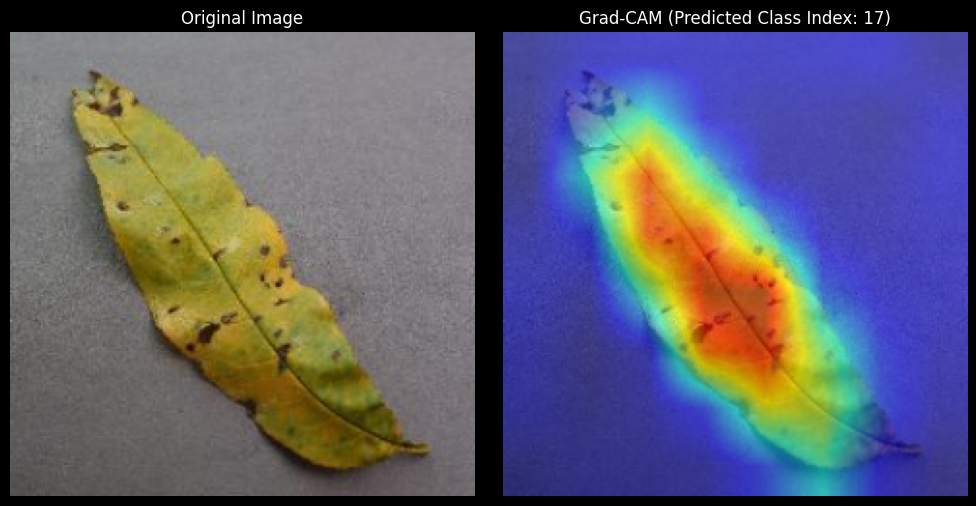

In [ ]:

# --- 1. Setup and Paths ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
base_dir = 'D:/AIDL/PlantVillage_Project'
model_path = os.path.join(base_dir, 'trained_models', 'EfficientNet-B1.pth')

# Replace this with the path to a specific test image you want to check
# (e.g., grab one from your quarantined validation folder)
test_image_path = 'D:/AIDL/PlantVillage_Project/split_dataset/val/Peach___Bacterial_spot/image (269).JPG'

num_classes = 39
target_resolution = 240  # B1's native resolution

# --- 2. Load the Trained Model ---
print("Loading EfficientNet-B1...")
model = models.efficientnet_b1(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

# Load your custom weights
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

# --- 3. Identify the Target Layer ---
# Grad-CAM needs the last convolutional layer to extract the highest-level spatial features
target_layers = [model.features[-1]]

# --- 4. Prepare the Image ---
# We need TWO versions of the image:
# 1. A normalized tensor for the model to process
# 2. A raw RGB float image (values 0 to 1) for matplotlib to draw the heatmap onto

# Read and resize raw image for visualization
raw_img = cv2.imread(test_image_path)
raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
raw_img = cv2.resize(raw_img, (target_resolution, target_resolution))
# Scale to [0, 1] for the overlay function
rgb_img = np.float32(raw_img) / 255.0

# Create the exact transform used during training for the model input
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
input_tensor = transform(raw_img).unsqueeze(0).to(device)

# --- 5. Generate Grad-CAM ---
print("Generating Grad-CAM heatmap...")

# Initialize the CAM object
cam = GradCAM(model=model, target_layers=target_layers)

# We want the heatmap for the class the model is MOST confident in
# (Setting targets=None automatically targets the highest scoring category)
targets = None

# Generate the raw heatmap (returns a batch, we take the first [0])
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

# Overlay the heatmap onto the original RGB image
visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

# --- 6. Display the Results ---
# Get the model's prediction to display in the title
with torch.no_grad():
    outputs = model(input_tensor)
    predicted_class_idx = outputs.argmax(dim=1).item()

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(rgb_img)
axs[0].set_title("Original Image")
axs[0].axis('off')

axs[1].imshow(visualization)
axs[1].set_title(f"Grad-CAM (Predicted Class Index: {predicted_class_idx})")
axs[1].axis('off')

plt.tight_layout()
plt.show()


### **Batch Grad-CAM Generation & Automated Interpretability**

#### **Objective & Context**
The objective of this code block is to scale Explainable AI (XAI) from a single-image diagnostic into a robust, automated batch process. It randomly samples 50 images from the validation set, runs them through the fine-tuned EfficientNet-B1 model, and generates side-by-side comparative plots (original vs. Grad-CAM). It introduces dynamic visual feedback (color-coding correct vs. incorrect predictions) and implements strict memory management to handle the generation of dozens of high-resolution Matplotlib figures without crashing system RAM.

#### **Deep Dive: Code Mechanics**
* **1. Label Mapping (`temp_dataset`):**
  * The script instantiates a temporary `ImageFolder` pointing to the validation directory. It doesn't actually load the images here; it strictly uses it to steal PyTorch's internal `class_to_idx` dictionary, reversing it into `idx_to_class` so the integer predictions (e.g., `14`) can be mapped back to human-readable strings (e.g., `Peach___Bacterial_spot`).
* **2. Random Sampling (`random.sample`):**
  * `glob.glob` grabs all file paths in the validation tree. A list comprehension filters out non-image files, and `random.sample` securely picks exactly 50 distinct paths to process, ensuring a diverse interpretability audit.
* **3. Object Initialization Outside the Loop:**
  * The `cam = GradCAM(...)` object is instantiated *once*, before the loop begins. Re-initializing the CAM hooks inside the loop for every image would introduce massive computational overhead and severely slow down the script.
* **4. The Processing Loop:**
  * **Dynamic Ground Truth:** `os.path.basename(os.path.dirname(img_path))` cleverly extracts the true class name directly from the folder structure.
  * **Visual vs. Tensor Tracks:** The script prepares `rgb_img` (a scaled float32 array for visualization) and `input_tensor` (the mathematically normalized input for the network).
  * **Inference Pass:** A standard forward pass wrapped in `with torch.no_grad():` extracts the model's top prediction without tracking gradients, saving compute.
  * **Gradient Pass:** The `cam()` call specifically *does* calculate gradients backward to the `target_layers` (the last convolutional block) to generate the `grayscale_cam` heatmap.
* **5. Conditional Plotting & Memory Management:**
  * The script uses a conditional ternary operator to set `title_color` to `darkgreen` if the prediction matches the ground truth, and `darkred` if the model made a mistake.
  * **`plt.close(fig)`:** This is the most critical engineering line in the loop. Matplotlib retains figure objects in system RAM until explicitly told to dump them. Rendering 50 high-DPI (`dpi=150`) figures consecutively would cause a memory leak and crash the Python kernel. Closing the figure immediately after `fig.savefig()` frees the memory pointer.

#### **Machine Learning Theory: Batch Interpretability & Visual Auditing**
* **Why Batch Auditing?** Checking a single Grad-CAM image is prone to confirmation bias. By automating the generation of 50 random heatmaps, a machine learning engineer can rapidly scan the output folder to look for systematic flaws. For example, if all the "red" (incorrect) predictions highlight a specific type of shadow or background dirt rather than the leaf itself, it reveals that the model has learned a confounding variable rather than the actual pathology.
* **Gradient Isolation:** Notice that the raw prediction (`outputs.argmax`) is calculated inside a `torch.no_grad()` block, but the `cam()` generation is not. Grad-CAM mathematically requires the autograd engine to be active so it can compute the derivative of the predicted class score with respect to the feature map activations of the final convolutional layer. This architectural separation ensures optimal efficiency.

#### **Data & State Flow**
* **Inputs:** 
  1. The validation directory (`split_dataset/val`).
  2. The fine-tuned EfficientNet-B1 weights (`EfficientNet-B1.pth`).
* **Outputs (Artifacts):** 
  1. A new local directory named `gradcam_outputs`.
  2. 50 high-resolution `.png` (or `.jpg`) images saved to that directory. Each image features a color-coded title (Green = Correct, Red = Incorrect) and a heatmap overlaid on the leaf.
  3. Terminal printouts tracking the script's progress every 10 images.

In [ ]:

# --- 1. Setup and Paths ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
base_dir = 'D:/AIDL/PlantVillage_Project'
model_path = os.path.join(base_dir, 'trained_models', 'EfficientNet-B1.pth')
val_dir = os.path.join(base_dir, 'split_dataset', 'val')

# Create the new folder for the output images
output_dir = os.path.join(base_dir, 'gradcam_outputs')
os.makedirs(output_dir, exist_ok=True)

# Apply Seaborn styling (White background with dark grid elements)
sns.set_theme(style="whitegrid")

num_classes = 39
target_resolution = 240  # B1's native resolution

# --- 2. Get Class Names & Select 50 Random Images ---
# Quick trick to get the mapping of index (0-38) back to string class names
temp_dataset = ImageFolder(root=val_dir)
idx_to_class = {v: k for k, v in temp_dataset.class_to_idx.items()}

# Find all images in the validation folder and pick 50
all_val_images = glob.glob(os.path.join(val_dir, '*/*.*'))
all_val_images = [img for img in all_val_images if img.lower().endswith(
    ('.png', '.jpg', '.jpeg'))]

NUM_IMAGES = 50
selected_images = random.sample(
    all_val_images, min(NUM_IMAGES, len(all_val_images)))
print(f"Selected {len(selected_images)} random images for Grad-CAM analysis.")

# --- 3. Load the Trained Model ---
print("Loading EfficientNet-B1...")
model = models.efficientnet_b1(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

# Grad-CAM needs the last convolutional layer
target_layers = [model.features[-1]]

# Initialize the CAM object ONCE outside the loop to save time
cam = GradCAM(model=model, target_layers=target_layers)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- 4. Processing Loop ---
print(f"Generating heatmaps and saving to: {output_dir}")

for i, img_path in enumerate(selected_images):
    # Extract true class name from the folder structure for labeling
    true_class = os.path.basename(os.path.dirname(img_path))
    original_filename = os.path.basename(img_path)

    # Read and format image
    raw_img = cv2.imread(img_path)
    if raw_img is None:
        continue

    raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
    raw_img = cv2.resize(raw_img, (target_resolution, target_resolution))
    rgb_img = np.float32(raw_img) / 255.0

    input_tensor = transform(raw_img).unsqueeze(0).to(device)

    # Get model prediction
    with torch.no_grad():
        outputs = model(input_tensor)
        predicted_class_idx = outputs.argmax(dim=1).item()
        pred_class_name = idx_to_class[predicted_class_idx]

    # Generate the heatmap
    grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    # --- Plotting ---
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    axs[0].imshow(rgb_img)
    axs[0].set_title(f"True: {true_class}", fontsize=11, weight='bold', pad=10)
    axs[0].axis('off')

    axs[1].imshow(visualization)

    # Color the title text green if correct, red if incorrect
    title_color = 'darkgreen' if true_class == pred_class_name else 'darkred'
    axs[1].set_title(f"Pred: {pred_class_name}", fontsize=11,
                     weight='bold', color=title_color, pad=10)
    axs[1].axis('off')

    plt.tight_layout()

    # --- Saving ---
    # Create a safe filename (replace spaces or weird characters if needed)
    save_name = f"CAM_{i+1:02d}_{true_class}_{original_filename}"
    save_path = os.path.join(output_dir, save_name)

    # Save the figure with a high DPI for crisp quality
    fig.savefig(save_path, dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())

    # CRITICAL: Close the figure to free up RAM!
    plt.close(fig)

    if (i + 1) % 10 == 0:
        print(f"  Processed {i + 1}/{len(selected_images)} images...")

print("\nFinished! All 50 Grad-CAM plots have been saved successfully.")


Selected 50 random images for Grad-CAM analysis.
Loading EfficientNet-B1...
Generating heatmaps and saving to: D:/AIDL/PlantVillage_Project\gradcam_outputs
  Processed 10/50 images...
  Processed 20/50 images...
  Processed 30/50 images...
  Processed 40/50 images...
  Processed 50/50 images...

Finished! All 50 Grad-CAM plots have been saved successfully.


# Quantization

## GPU FP16

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import os
import pandas as pd
import numpy as np

# --- 1. Custom Model Definition ---


class CNN(nn.Module):
    def __init__(self, K):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3,
                      padding=1), nn.ReLU(), nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.ReLU(
            ), nn.BatchNorm2d(32), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3,
                      padding=1), nn.ReLU(), nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(
            ), nn.BatchNorm2d(64), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3,
                      padding=1), nn.ReLU(), nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.ReLU(
            ), nn.BatchNorm2d(128), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3,
                      padding=1), nn.ReLU(), nn.BatchNorm2d(256),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(
            ), nn.BatchNorm2d(256), nn.MaxPool2d(2),
            nn.Conv2d(256, 256, kernel_size=3,
                      padding=1), nn.ReLU(), nn.BatchNorm2d(256),
        )
        self.dense_layers = nn.Sequential(
            nn.Dropout(0.4), nn.Linear(50176, 1024), nn.ReLU(),
            nn.Dropout(0.4), nn.Linear(1024, K),
        )

    def forward(self, X):
        out = self.conv_layers(X)
        out = torch.flatten(out, 1)
        out = self.dense_layers(out)
        return out


# --- 2. Setup & GPU Architecture ---
# Force CUDA and enable cudnn benchmarking for optimal convolution selection
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
print(
    f"Executing FP16 Compression & Benchmarking on: {torch.cuda.get_device_name(0)}")

base_dir = './PlantVillage_Project'
models_dir = os.path.join(base_dir, 'trained_models')
fp16_dir = os.path.join(base_dir, 'fp16_models')
val_dir = os.path.join(base_dir, 'split_dataset', 'val')
os.makedirs(fp16_dir, exist_ok=True)

# Map config: 'ModelName': (builder_function, target_resolution, file_extension)
model_configs = {
    'baseline_9_layer_CNN': (CNN, 224, 'pt'),
    'EfficientNet-B0': (models.efficientnet_b0, 224, 'pth'),
    'EfficientNet-B1': (models.efficientnet_b1, 240, 'pth'),
    'EfficientNet-B2': (models.efficientnet_b2, 260, 'pth'),
    'MobileNetV3-Large': (models.mobilenet_v3_large, 224, 'pth'),
    'ResNet34': (models.resnet34, 224, 'pth')
}

# --- 3. Main Compression & Evaluation Loop ---
benchmark_results = []

for model_name, (builder, target_resolution, ext) in model_configs.items():
    fp32_path = os.path.join(models_dir, f"{model_name}.{ext}")
    fp16_save_path = os.path.join(fp16_dir, f"{model_name}_FP16.pt")

    if not os.path.exists(fp32_path):
        print(f"\nSkipping {model_name} - Original FP32 weights not found.")
        continue

    print(f"\n=======================================================")
    print(f"--- Compressing & Benchmarking: {model_name} (FP16) ---")

    # A. Data Loading
    transform = transforms.Compose([
        transforms.Resize((target_resolution, target_resolution)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[
                             0.229, 0.224, 0.225])
    ])
    val_dataset = ImageFolder(root=val_dir, transform=transform)
    num_classes = len(val_dataset.classes)

    # Enable pin_memory for faster CPU->GPU transfer
    val_loader = DataLoader(val_dataset, batch_size=32,
                            shuffle=False, num_workers=4, pin_memory=True)

    # B. Load FP32 Architecture & Weights
    if model_name == 'baseline_9_layer_CNN':
        model = builder(K=num_classes)
    else:
        model = builder(weights=None)
        if hasattr(model, 'classifier') and isinstance(model.classifier, nn.Sequential):
            in_feat = model.classifier[-1].in_features
            model.classifier[-1] = nn.Linear(in_feat, num_classes)
        elif hasattr(model, 'fc'):
            in_feat = model.fc.in_features
            model.fc = nn.Linear(in_feat, num_classes)

    model.load_state_dict(torch.load(fp32_path, map_location=device))

    # C. Convert to Half Precision (FP16)
    model = model.half().to(device)
    model.eval()

    total_params = sum(p.numel() for p in model.parameters())

    # Save the FP16 Traced Model
    torch.save(model.state_dict(), fp16_save_path)
    disk_size_mb = os.path.getsize(fp16_save_path) / (1024 * 1024)
    print(f"Successfully converted to FP16. New Size: {disk_size_mb:.2f} MB")

    # D. GPU-Synchronized Inference & Benchmarking
    print("Running full validation benchmark on Tensor Cores...")
    all_preds = []
    all_labels = []

    # We must use CUDA events to measure GPU time properly, not time.time()
    starter, ender = torch.cuda.Event(
        enable_timing=True), torch.cuda.Event(enable_timing=True)
    inference_times = []

    # Warmup GPU
    dummy_input = torch.randn(1, 3, target_resolution,
                              target_resolution).half().to(device)
    for _ in range(10):
        _ = model(dummy_input)

    with torch.no_grad():
        for images, labels in val_loader:
            # Inputs must also be converted to FP16 to match the model weights
            images = images.half().to(device)
            labels = labels.to(device)

            # Start timer
            starter.record()

            # Forward pass using Mixed Precision Autocast
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                outputs = model(images)

            # End timer
            ender.record()
            torch.cuda.synchronize()  # Wait for GPU math to finish

            # Calculate batch time and convert to ms per image
            batch_time_ms = starter.elapsed_time(ender)
            ms_per_image = batch_time_ms / images.size(0)
            inference_times.append(ms_per_image)

            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate Metrics
    avg_inference_ms = np.mean(inference_times)
    accuracy = accuracy_score(all_labels, all_preds) * 100
    macro_prec, macro_rec, macro_f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0
    )

    print(
        f"Results: {accuracy:.2f}% Acc | {avg_inference_ms:.2f} ms/img GPU | {disk_size_mb:.2f} MB Disk")

    # E. Store Data
    benchmark_results.append({
        'Model': f"{model_name} (FP16)",
        'Resolution': f"{target_resolution}x{target_resolution}",
        'Accuracy (%)': round(accuracy, 2),
        'Macro Precision': round(macro_prec, 4),
        'Macro Recall': round(macro_rec, 4),
        'Macro F1-Score': round(macro_f1, 4),
        'Inference Time (ms/img)': round(avg_inference_ms, 2),
        'Disk Space (MB)': round(disk_size_mb, 1),
        'Total Parameters (Millions)': round(total_params / 1_000_000, 2)
    })

    # Flush GPU memory before loading the next architecture
    del model, images, labels, outputs
    torch.cuda.empty_cache()

# --- 4. Export Master Report ---
if benchmark_results:
    df_eval = pd.DataFrame(benchmark_results)
    print("\n=======================================================")
    print("--- Final FP16 GPU Benchmarks ---")
    print("=======================================================\n")
    print(df_eval.to_string(index=False))

    eval_csv_path = os.path.join(base_dir, 'FP16_GPU_Benchmarks.csv')
    df_eval.to_csv(eval_csv_path, index=False)
    print(f"\nSaved overall FP16 benchmarks to: {eval_csv_path}")


Executing FP16 Compression & Benchmarking on: NVIDIA GeForce RTX 5060 Laptop GPU

--- Compressing & Benchmarking: baseline_9_layer_CNN (FP16) ---
Successfully converted to FP16. New Size: 101.47 MB
Running full validation benchmark on Tensor Cores...
Results: 92.85% Acc | 0.88 ms/img GPU | 101.47 MB Disk

--- Compressing & Benchmarking: EfficientNet-B0 (FP16) ---
Successfully converted to FP16. New Size: 7.95 MB
Running full validation benchmark on Tensor Cores...
Results: 98.82% Acc | 1.68 ms/img GPU | 7.95 MB Disk

--- Compressing & Benchmarking: EfficientNet-B1 (FP16) ---
Successfully converted to FP16. New Size: 12.82 MB
Running full validation benchmark on Tensor Cores...
Results: 99.17% Acc | 2.16 ms/img GPU | 12.82 MB Disk

--- Compressing & Benchmarking: EfficientNet-B2 (FP16) ---
Successfully converted to FP16. New Size: 15.10 MB
Running full validation benchmark on Tensor Cores...
Results: 99.05% Acc | 2.13 ms/img GPU | 15.10 MB Disk

--- Compressing & Benchmarking: MobileNet

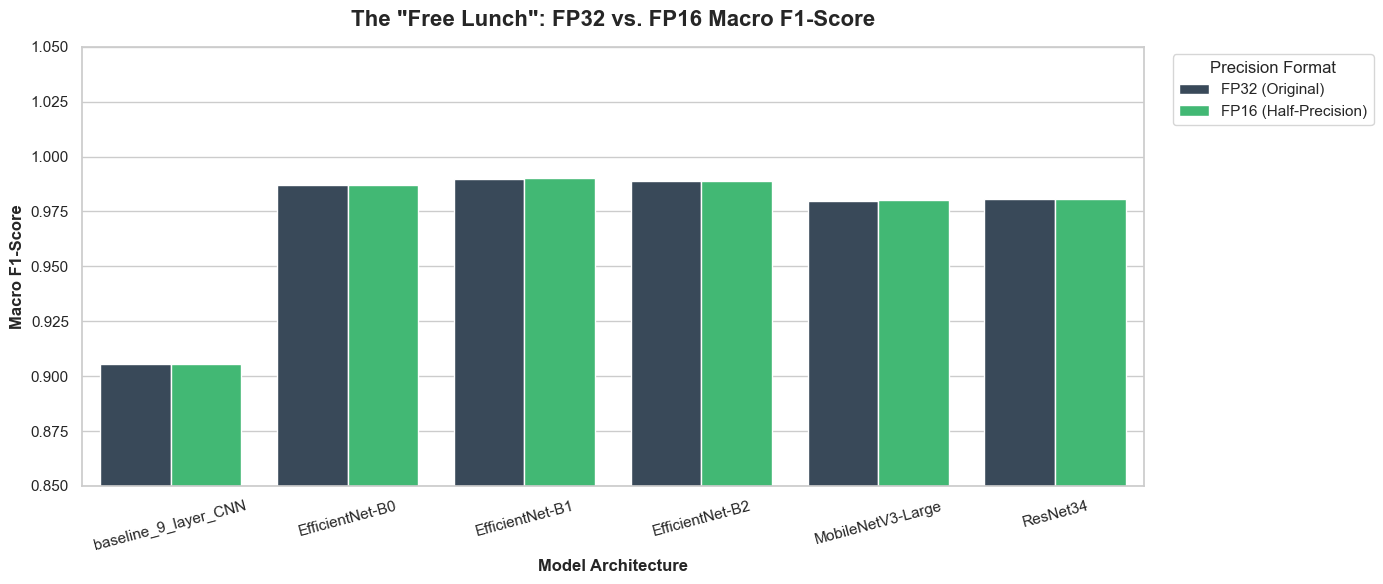

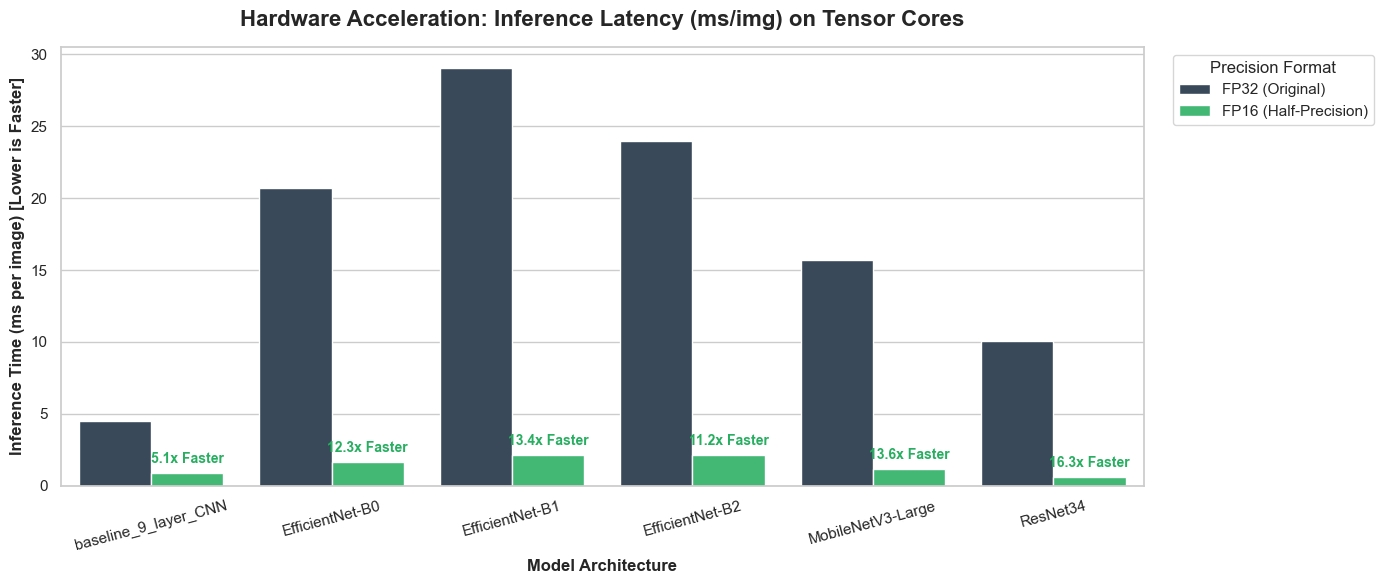

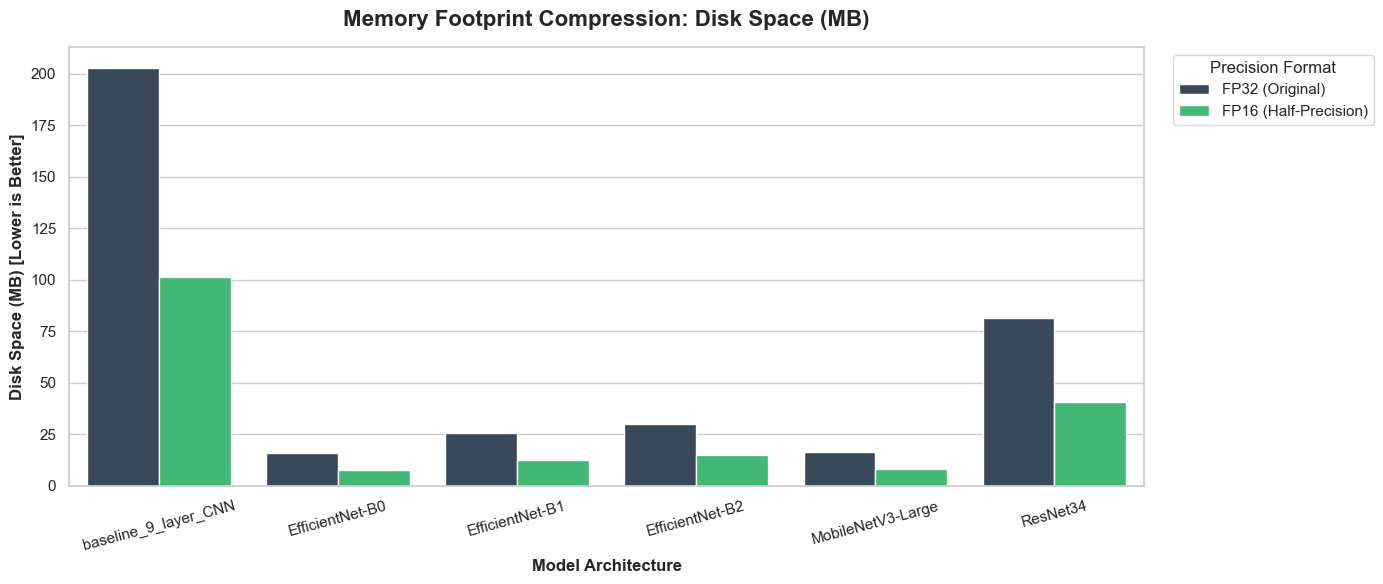

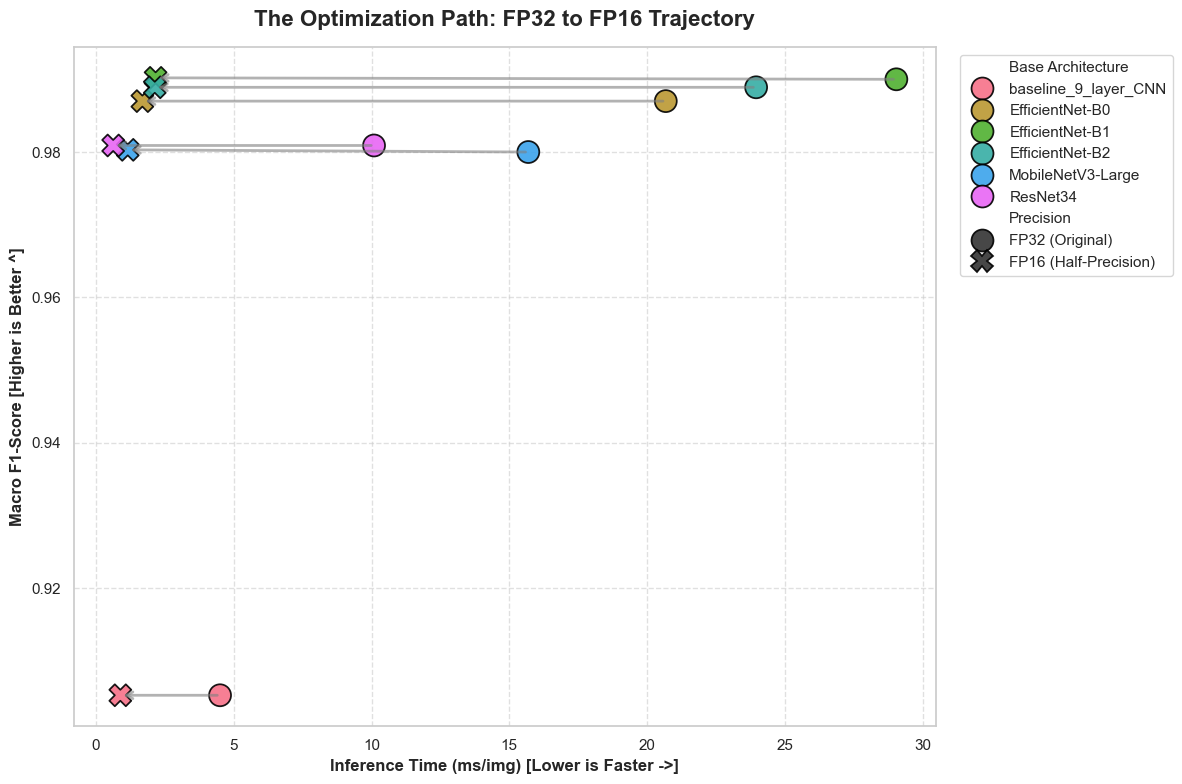

✅ All 4 comparative visualizations have been generated, displayed, and saved.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os


def generate_comparative_visualizations():
    # 1. Load the Datasets
    df_fp32 = pd.read_csv(
        'D:/AIDL/PlantVillage_Project/PostTraining_Macro_Benchmarks.csv')
    df_fp16 = pd.read_csv(
        'D:/AIDL/PlantVillage_Project/FP16_GPU_Benchmarks.csv')

    # 2. Add Precision labels for Seaborn Hue mapping
    df_fp32['Precision'] = 'FP32 (Original)'
    df_fp16['Precision'] = 'FP16 (Half-Precision)'

    # Clean FP16 model names so they match the FP32 names perfectly for grouped plotting
    df_fp16['Base Architecture'] = df_fp16['Model'].str.replace(
        r' \(FP16\)', '', regex=True)
    df_fp32['Base Architecture'] = df_fp32['Model']

    # Combine into a master DataFrame
    combined_df = pd.concat([df_fp32, df_fp16], ignore_index=True)

    # 3. Set Global Aesthetics
    sns.set_theme(style="whitegrid", palette="Set2")
    # Dark Blue & Emerald Green
    precision_palette = {'FP32 (Original)': '#34495e',
                         'FP16 (Half-Precision)': '#2ecc71'}

    # ==========================================
    # PLOT 1: The "Free Lunch" (Macro F1 Comparison)
    # ==========================================
    plt.figure(figsize=(14, 6))
    ax = sns.barplot(data=combined_df, x='Base Architecture',
                     y='Macro F1-Score', hue='Precision', palette=precision_palette)
    plt.title('The "Free Lunch": FP32 vs. FP16 Macro F1-Score',
              fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Model Architecture', fontsize=12, fontweight='bold')
    plt.ylabel('Macro F1-Score', fontsize=12, fontweight='bold')

    # Zoomed in Y-axis because the scores are nearly identical (shows the lack of degradation)
    plt.ylim(0.85, 1.05)
    plt.xticks(rotation=15)
    plt.legend(title='Precision Format',
               bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout()
    plt.savefig('01_fp32_vs_fp16_f1_score.png', dpi=300)
    plt.show()

    # ==========================================
    # PLOT 2: Hardware Acceleration (Latency)
    # ==========================================
    plt.figure(figsize=(14, 6))
    ax = sns.barplot(data=combined_df, x='Base Architecture',
                     y='Inference Time (ms/img)', hue='Precision', palette=precision_palette)
    plt.title('Hardware Acceleration: Inference Latency (ms/img) on Tensor Cores',
              fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Model Architecture', fontsize=12, fontweight='bold')
    plt.ylabel(
        'Inference Time (ms per image) [Lower is Faster]', fontsize=12, fontweight='bold')
    plt.xticks(rotation=15)
    plt.legend(title='Precision Format',
               bbox_to_anchor=(1.02, 1), loc='upper left')

    # Dynamically calculate and annotate the "X Faster" multiplier
    for arch in df_fp32['Base Architecture'].unique():
        fp32_val = df_fp32[df_fp32['Base Architecture']
                           == arch]['Inference Time (ms/img)'].values[0]
        fp16_val = df_fp16[df_fp16['Base Architecture']
                           == arch]['Inference Time (ms/img)'].values[0]
        speedup = fp32_val / fp16_val

        # Find the FP16 bar to place the text above it
        for p in ax.patches:
            if p.get_height() == fp16_val:
                ax.annotate(f"{speedup:.1f}x Faster",
                            (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#27ae60',
                            xytext=(0, 5), textcoords='offset points')
                break

    plt.tight_layout()
    plt.savefig('02_fp32_vs_fp16_latency.png', dpi=300)
    plt.show()

    # ==========================================
    # PLOT 3: Memory Compression (Disk Space)
    # ==========================================
    plt.figure(figsize=(14, 6))
    ax = sns.barplot(data=combined_df, x='Base Architecture',
                     y='Disk Space (MB)', hue='Precision', palette=precision_palette)
    plt.title('Memory Footprint Compression: Disk Space (MB)',
              fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Model Architecture', fontsize=12, fontweight='bold')
    plt.ylabel('Disk Space (MB) [Lower is Better]',
               fontsize=12, fontweight='bold')
    plt.xticks(rotation=15)
    plt.legend(title='Precision Format',
               bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout()
    plt.savefig('03_fp32_vs_fp16_disk_space.png', dpi=300)
    plt.show()

    # ==========================================
    # PLOT 4: The Optimization Trajectory (Scatter)
    # ==========================================
    # This chart visually tracks how moving from FP32 to FP16 pushes the model
    # horizontally to the left (faster) without dropping vertically (losing accuracy).
    plt.figure(figsize=(12, 8))

    # Plot the bubbles
    sns.scatterplot(data=combined_df, x='Inference Time (ms/img)', y='Macro F1-Score',
                    hue='Base Architecture', style='Precision', s=250, palette='husl', edgecolor='black', alpha=0.9)

    # Draw structural arrows connecting the FP32 state to the FP16 state
    for arch in df_fp32['Base Architecture'].unique():
        fp32_row = df_fp32[df_fp32['Base Architecture'] == arch].iloc[0]
        fp16_row = df_fp16[df_fp16['Base Architecture'] == arch].iloc[0]

        plt.annotate('',
                     xy=(fp16_row['Inference Time (ms/img)'],
                         fp16_row['Macro F1-Score']),
                     xytext=(fp32_row['Inference Time (ms/img)'],
                             fp32_row['Macro F1-Score']),
                     arrowprops=dict(arrowstyle="->", color='gray', lw=2, alpha=0.6))

    plt.title('The Optimization Path: FP32 to FP16 Trajectory',
              fontsize=16, fontweight='bold', pad=15)
    plt.xlabel(
        'Inference Time (ms/img) [Lower is Faster ->]', fontsize=12, fontweight='bold')
    plt.ylabel('Macro F1-Score [Higher is Better ^]',
               fontsize=12, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.savefig('04_optimization_trajectory.png', dpi=300)
    plt.show()

    print("✅ All 4 comparative visualizations have been generated, displayed, and saved.")


if __name__ == "__main__":
    generate_comparative_visualizations()


C:\Users\mim26\AppData\Local\Temp\ipykernel_9664\852023183.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=latencies, palette=colors, ax=ax2)
C:\Users\mim26\AppData\Local\Temp\ipykernel_9664\852023183.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=sizes, palette=colors, ax=ax3)
C:\Users\mim26\AppData\Local\Temp\ipykernel_9664\852023183.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=f1_scores, palette=colors, ax=ax4)


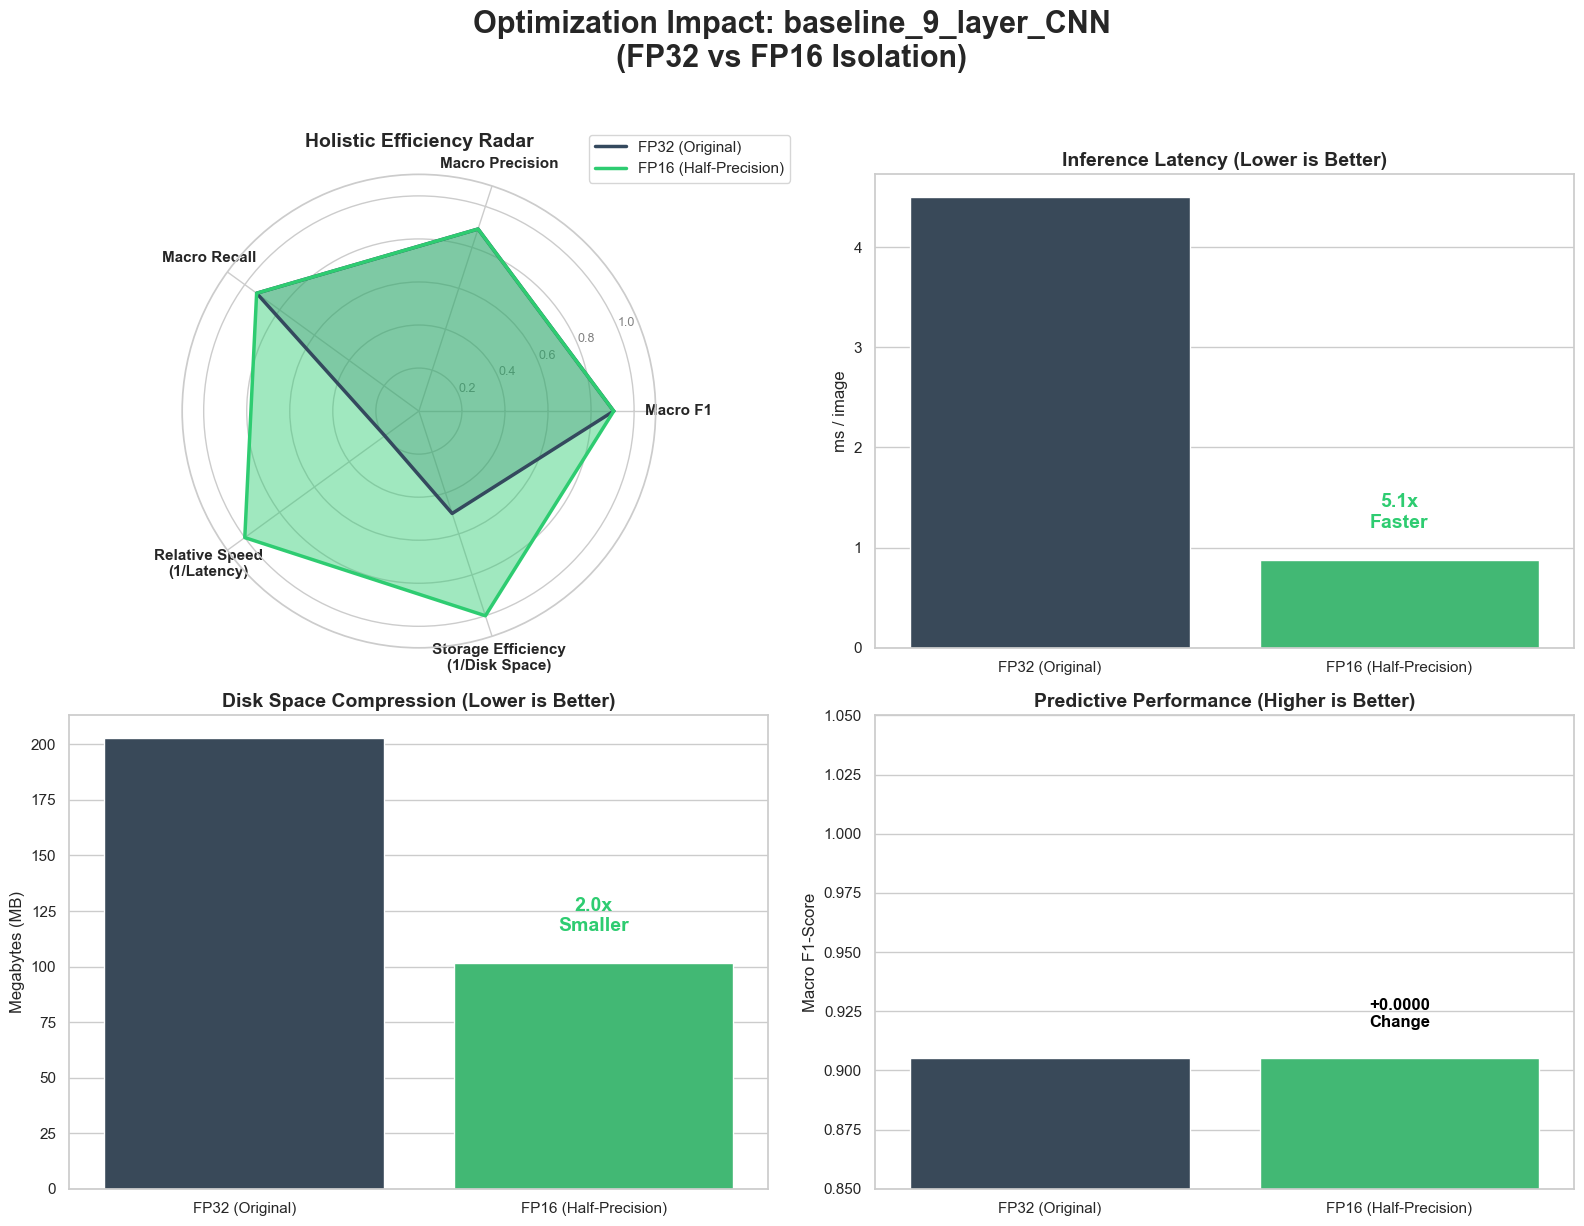

C:\Users\mim26\AppData\Local\Temp\ipykernel_9664\852023183.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=latencies, palette=colors, ax=ax2)
C:\Users\mim26\AppData\Local\Temp\ipykernel_9664\852023183.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=sizes, palette=colors, ax=ax3)
C:\Users\mim26\AppData\Local\Temp\ipykernel_9664\852023183.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=f1_scores, palette=colors, ax=ax4)


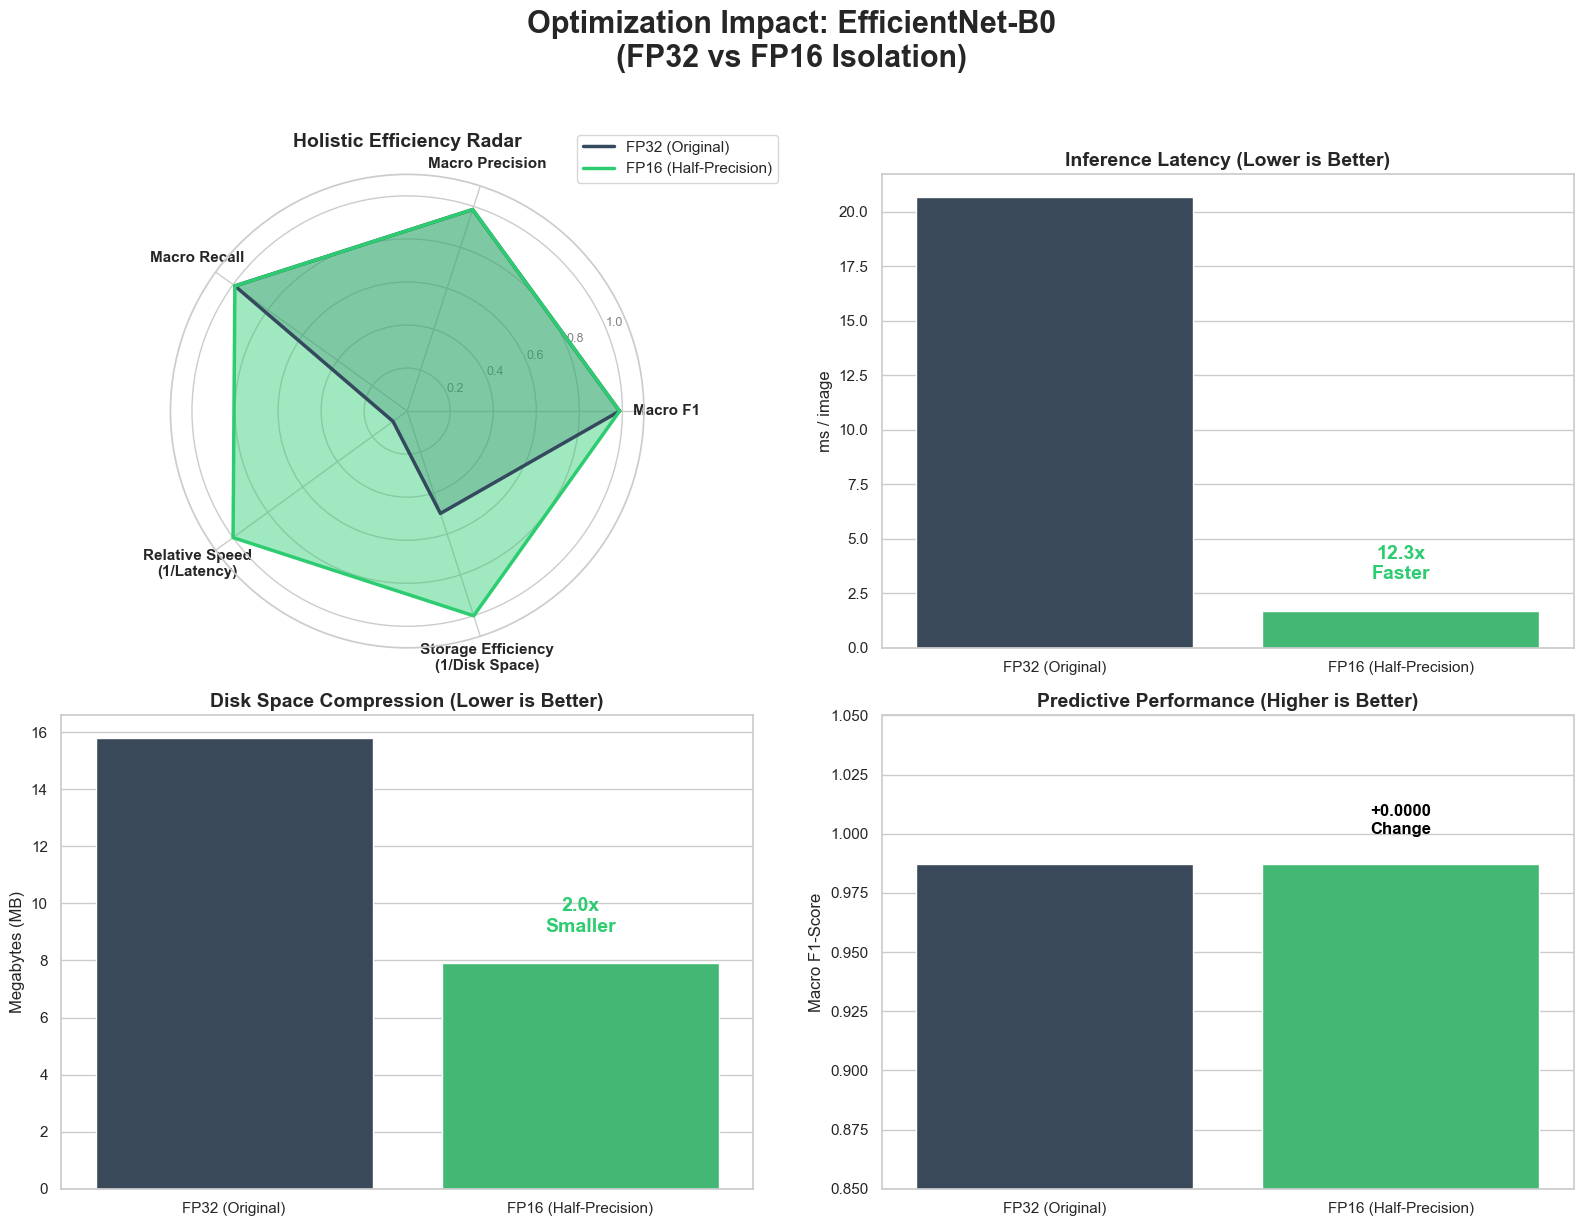

C:\Users\mim26\AppData\Local\Temp\ipykernel_9664\852023183.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=latencies, palette=colors, ax=ax2)
C:\Users\mim26\AppData\Local\Temp\ipykernel_9664\852023183.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=sizes, palette=colors, ax=ax3)
C:\Users\mim26\AppData\Local\Temp\ipykernel_9664\852023183.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=f1_scores, palette=colors, ax=ax4)


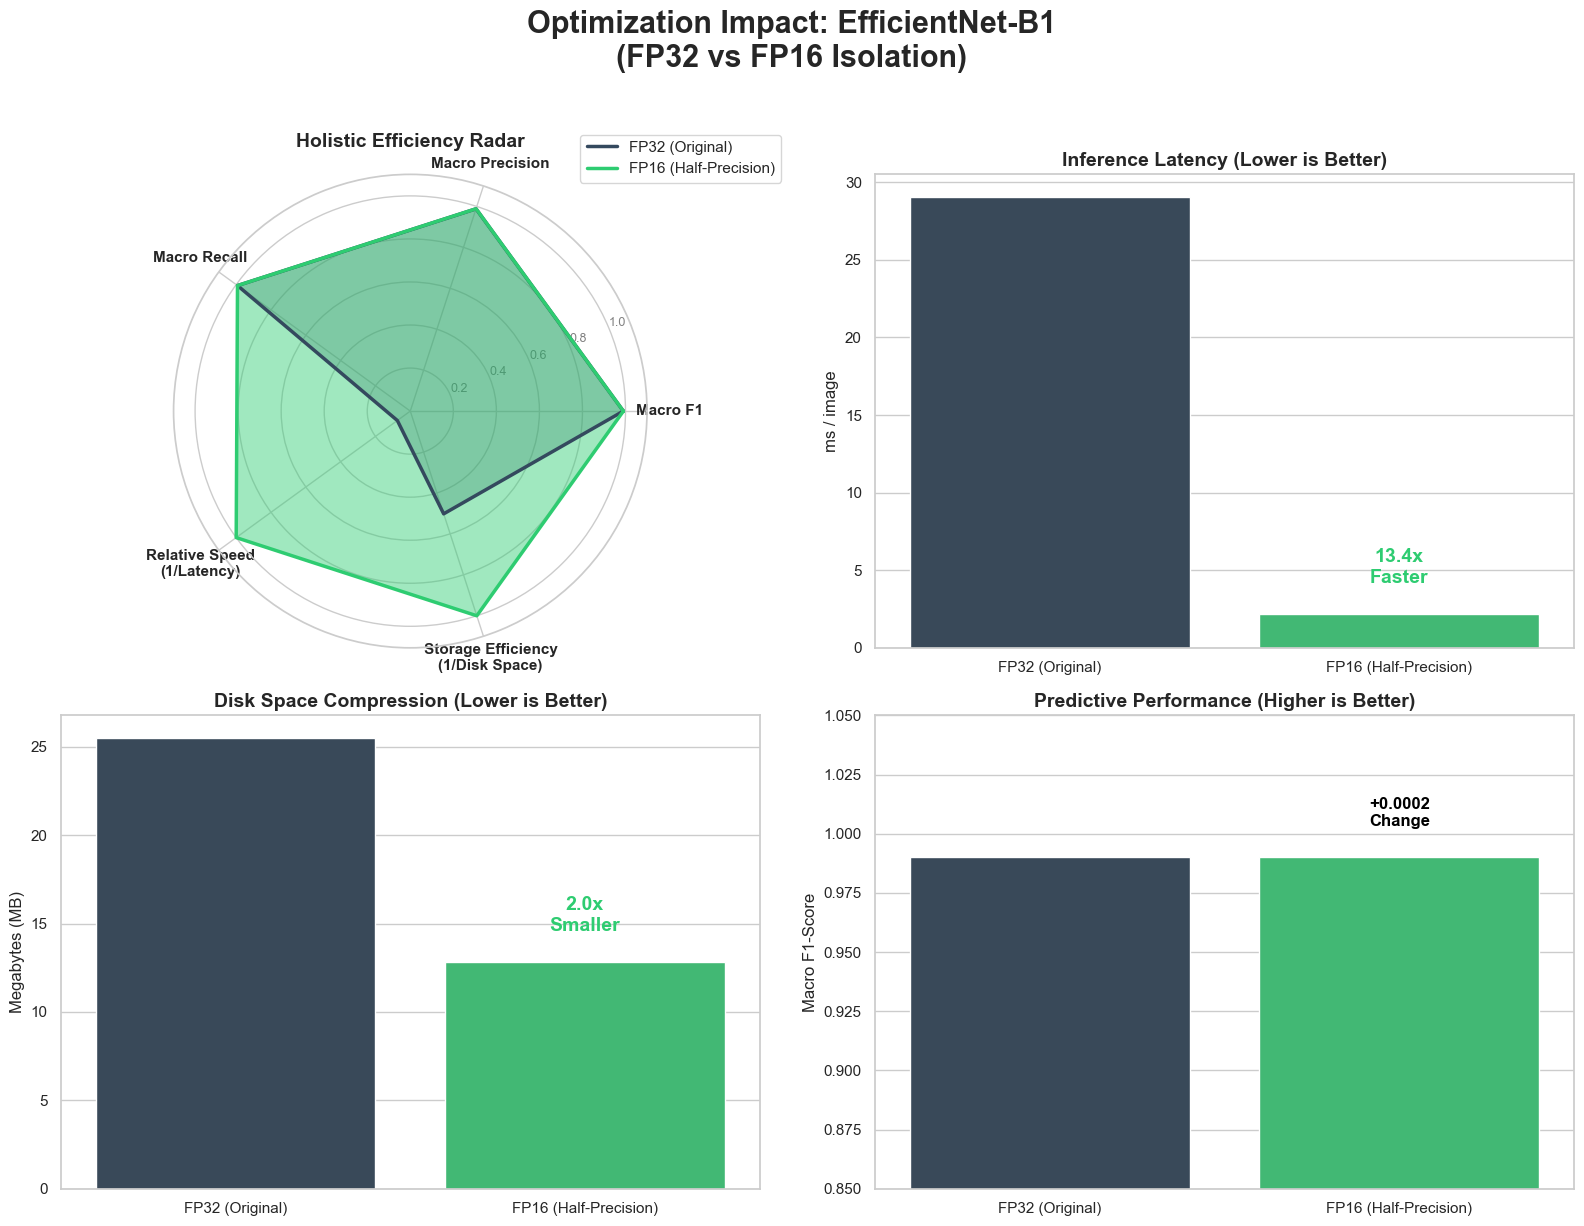

C:\Users\mim26\AppData\Local\Temp\ipykernel_9664\852023183.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=latencies, palette=colors, ax=ax2)
C:\Users\mim26\AppData\Local\Temp\ipykernel_9664\852023183.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=sizes, palette=colors, ax=ax3)
C:\Users\mim26\AppData\Local\Temp\ipykernel_9664\852023183.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=f1_scores, palette=colors, ax=ax4)


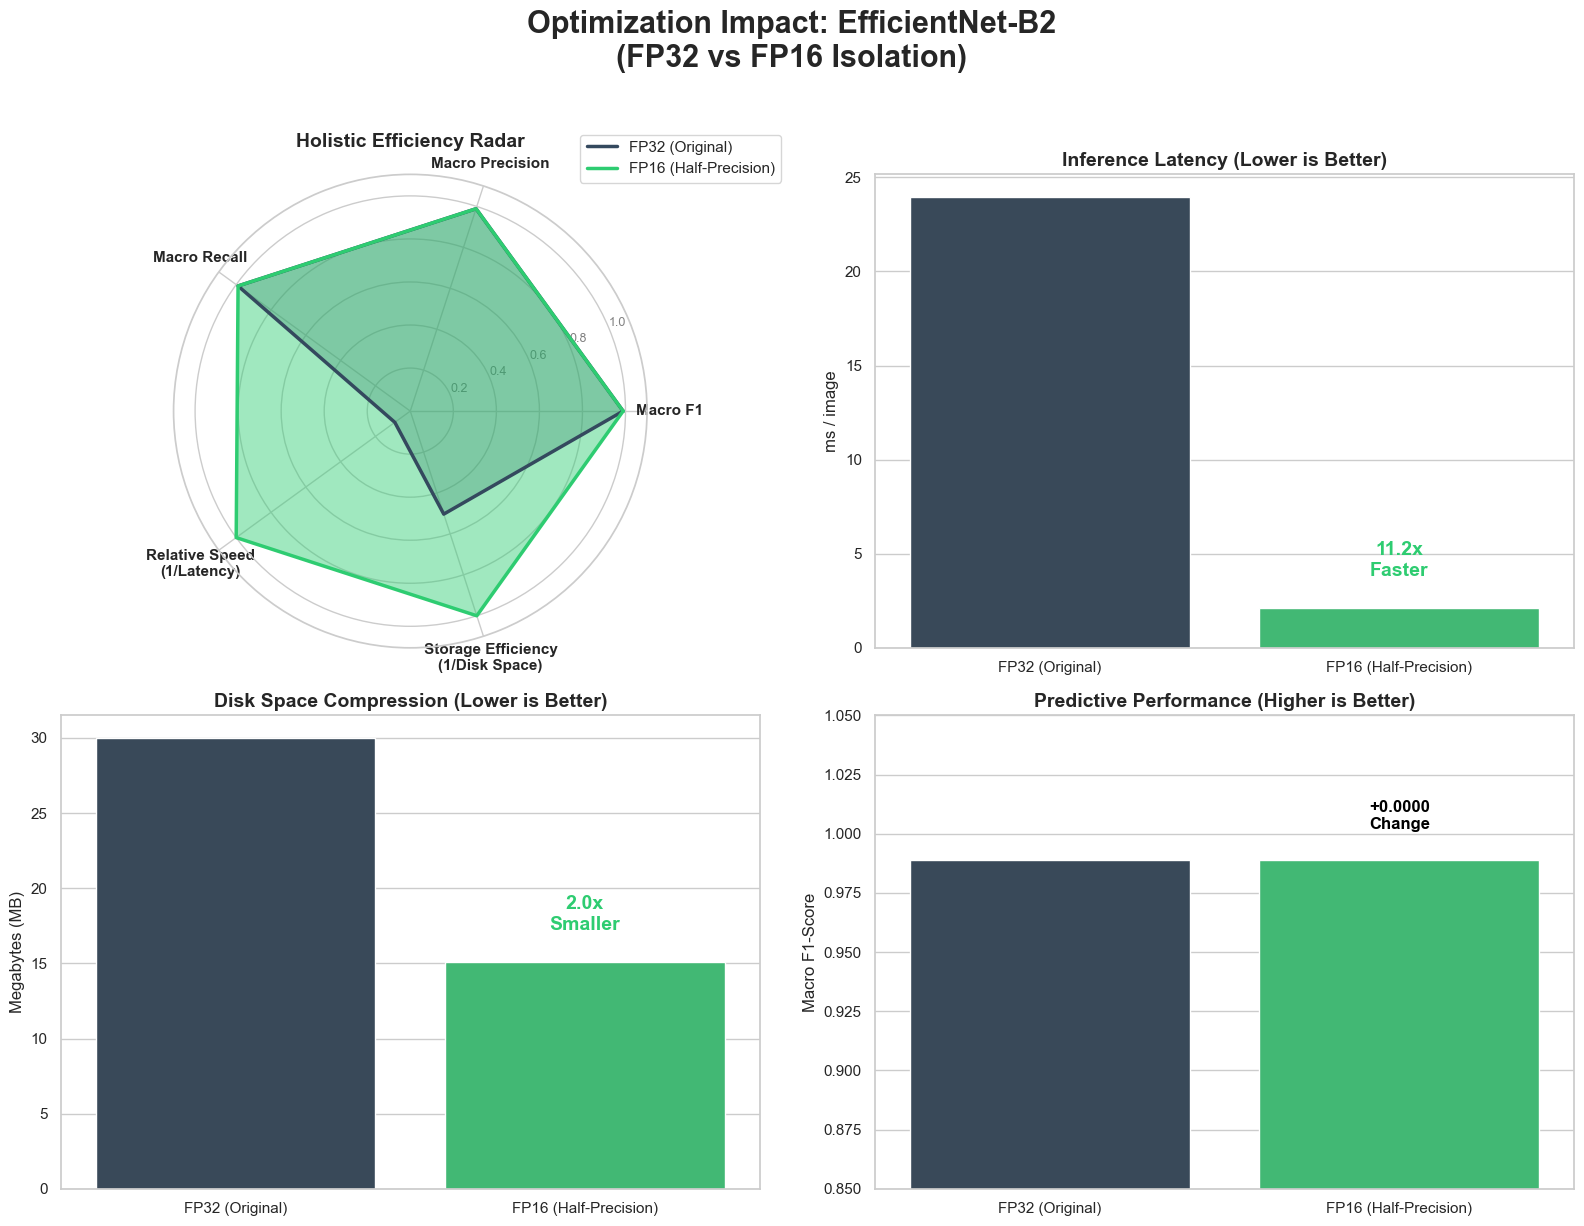

C:\Users\mim26\AppData\Local\Temp\ipykernel_9664\852023183.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=latencies, palette=colors, ax=ax2)
C:\Users\mim26\AppData\Local\Temp\ipykernel_9664\852023183.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=sizes, palette=colors, ax=ax3)
C:\Users\mim26\AppData\Local\Temp\ipykernel_9664\852023183.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=f1_scores, palette=colors, ax=ax4)


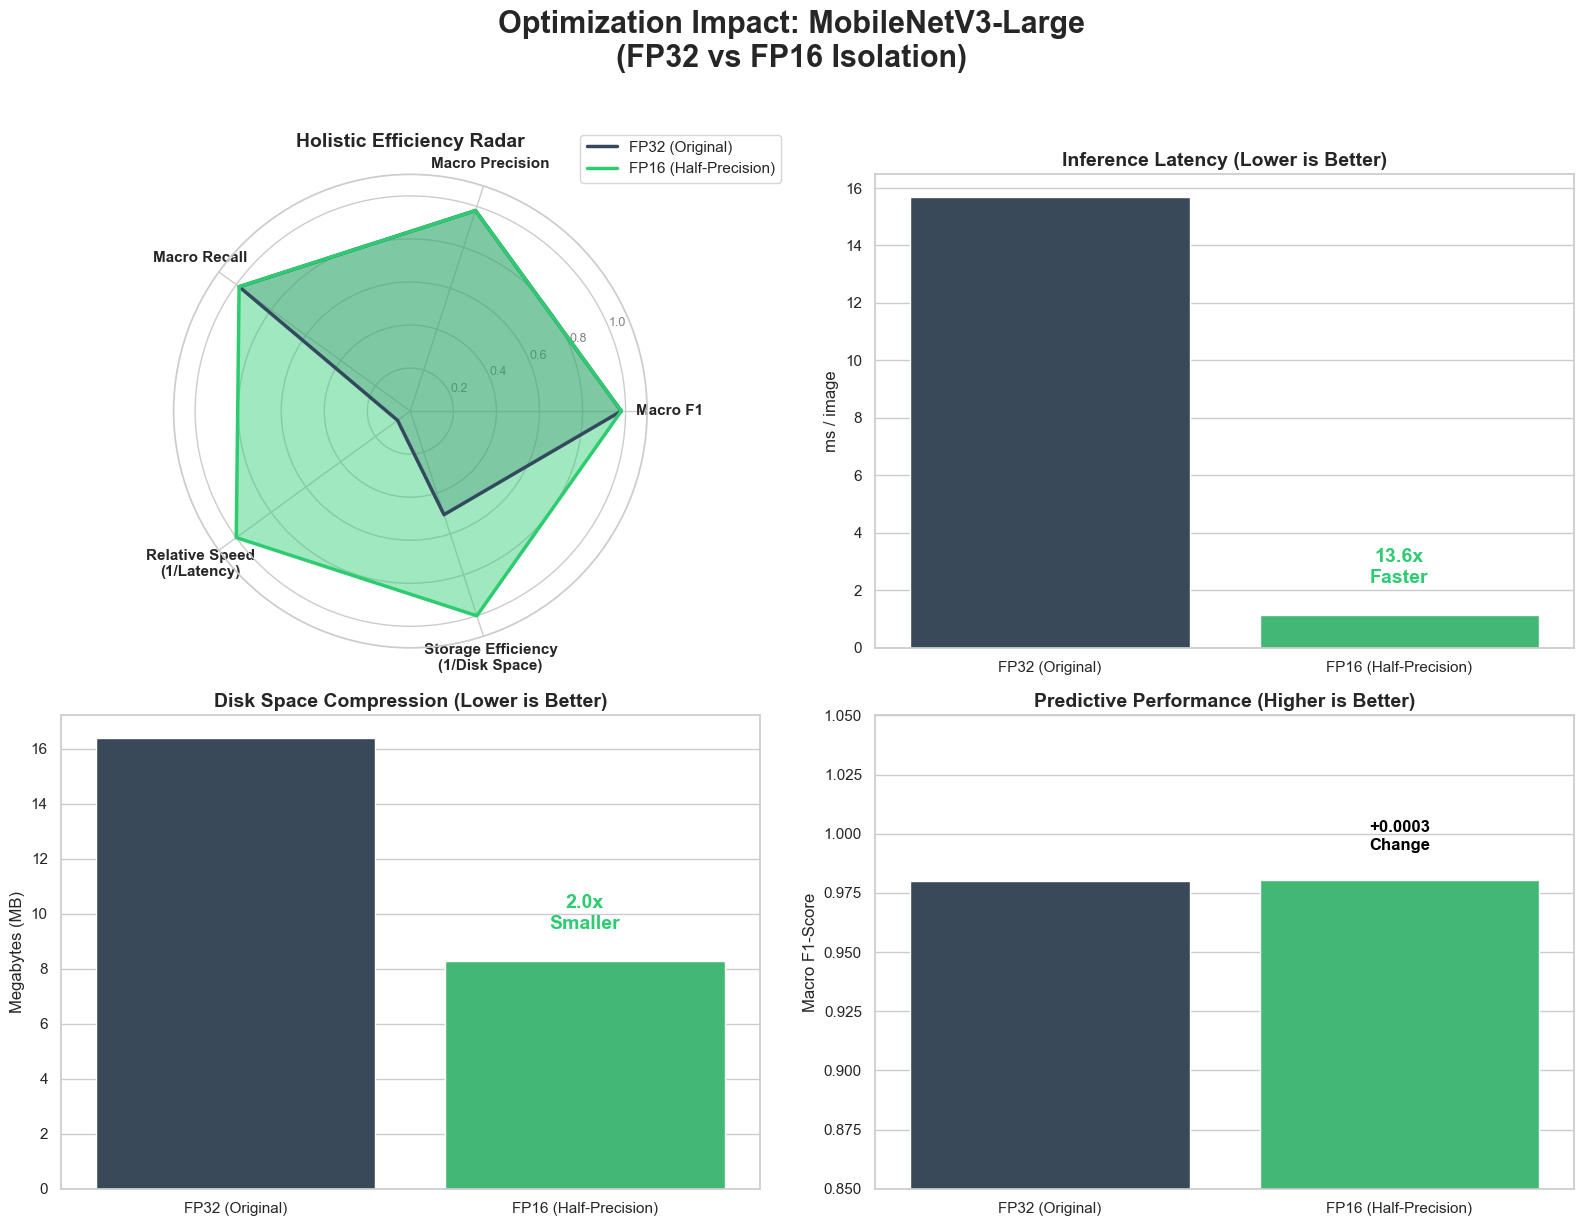

C:\Users\mim26\AppData\Local\Temp\ipykernel_9664\852023183.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=latencies, palette=colors, ax=ax2)
C:\Users\mim26\AppData\Local\Temp\ipykernel_9664\852023183.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=sizes, palette=colors, ax=ax3)
C:\Users\mim26\AppData\Local\Temp\ipykernel_9664\852023183.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=f1_scores, palette=colors, ax=ax4)


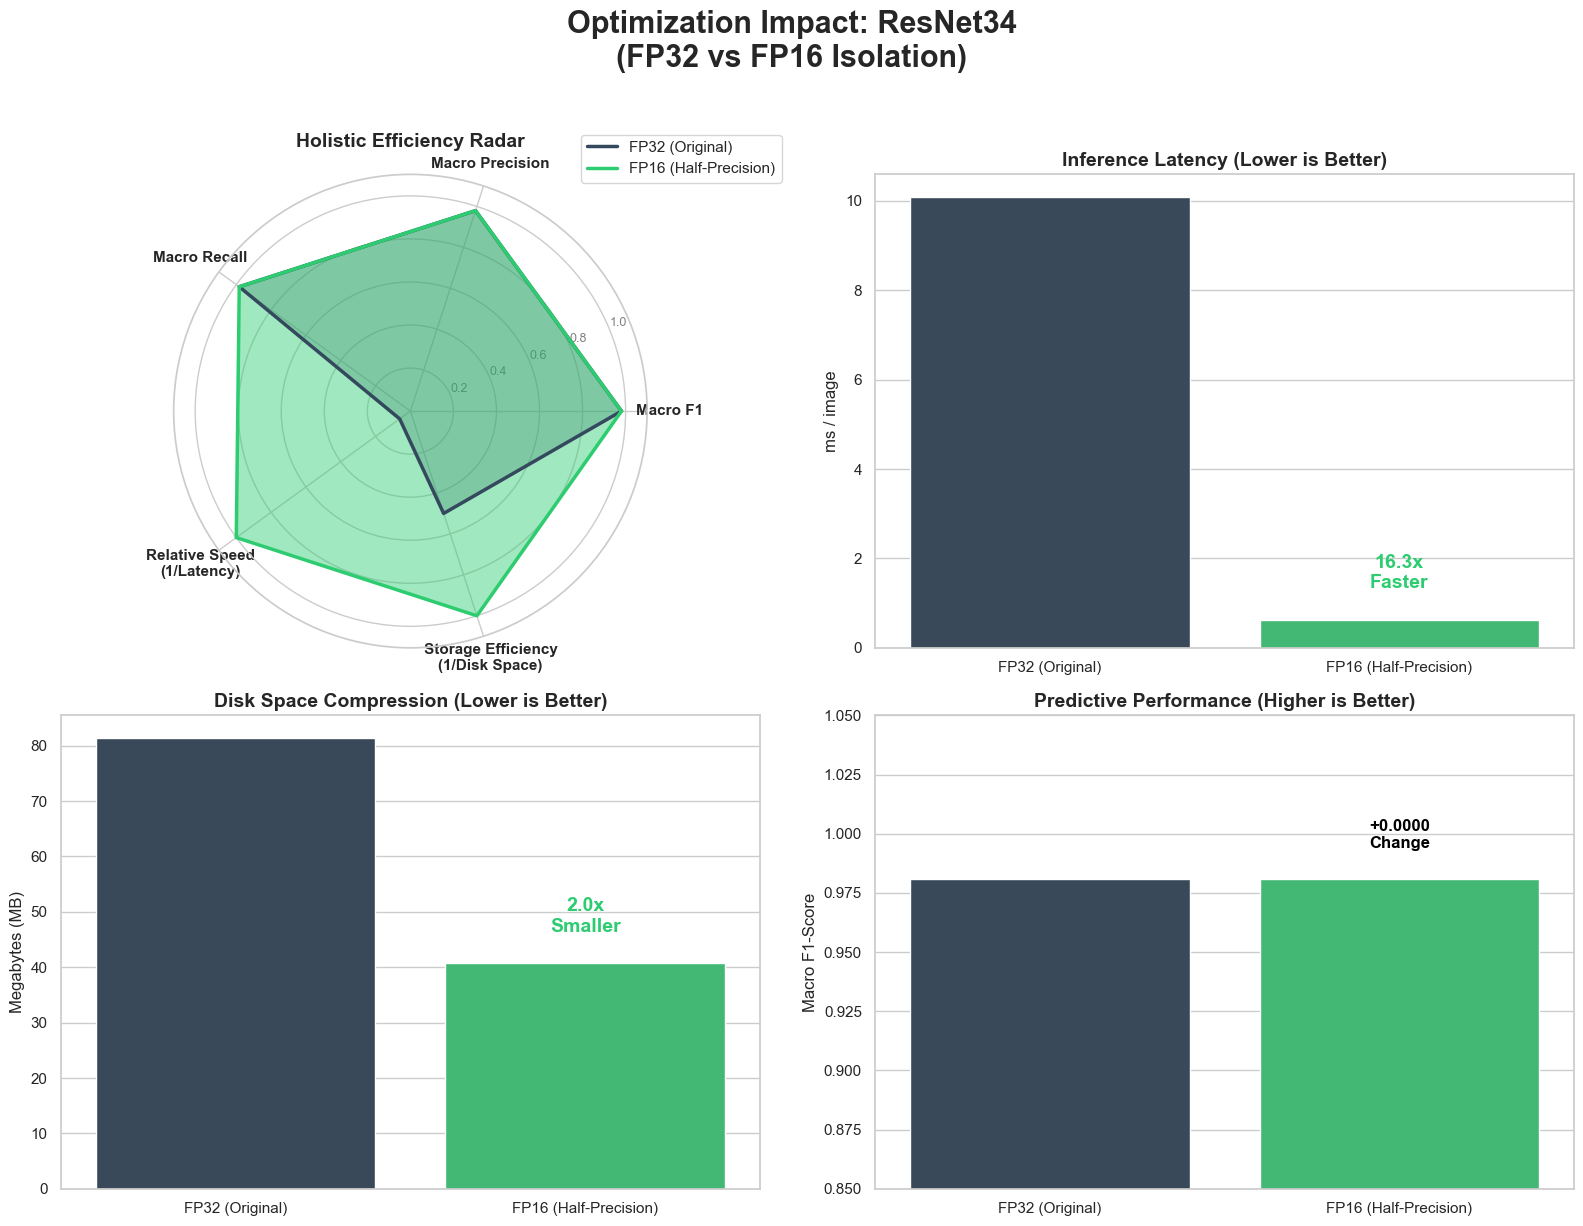

✅ All Architecture-Isolated Dashboards successfully generated and saved.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import pi
import os


def generate_isolated_architecture_reports():
    # 1. Load the Datasets
    df_fp32 = pd.read_csv(
        'D:/AIDL/PlantVillage_Project/PostTraining_Macro_Benchmarks.csv')
    df_fp16 = pd.read_csv(
        'D:/AIDL/PlantVillage_Project/FP16_GPU_Benchmarks.csv')

    # Clean names so we can match the FP32 and FP16 rows perfectly
    df_fp16['Base Architecture'] = df_fp16['Model'].str.replace(
        r' \(FP16\)', '', regex=True)
    df_fp32['Base Architecture'] = df_fp32['Model']

    architectures = df_fp32['Base Architecture'].unique()

    # 2. Set Global Aesthetics
    sns.set_theme(style="whitegrid")
    colors = ['#34495e', '#2ecc71']  # FP32 Dark Blue, FP16 Emerald Green
    labels = ['FP32 (Original)', 'FP16 (Half-Precision)']

    # 3. Generate a dedicated dashboard for EACH architecture
    for arch in architectures:
        # Extract data strictly for this specific architecture
        fp32_row = df_fp32[df_fp32['Base Architecture'] == arch].iloc[0]
        fp16_row = df_fp16[df_fp16['Base Architecture'] == arch].iloc[0]

        # Initialize a 2x2 grid for the dashboard
        fig = plt.figure(figsize=(16, 12))
        fig.suptitle(f'Optimization Impact: {arch}\n(FP32 vs FP16 Isolation)',
                     fontsize=22, fontweight='bold', y=1.02)

        # ==========================================
        # PANEL 1: The Radar Chart (Holistic Trade-off)
        # ==========================================
        ax1 = plt.subplot(2, 2, 1, polar=True)
        categories = ['Macro F1', 'Macro Precision', 'Macro Recall',
                      'Relative Speed\n(1/Latency)', 'Storage Efficiency\n(1/Disk Space)']
        N = len(categories)
        angles = [n / float(N) * 2 * pi for n in range(N)]
        angles += angles[:1]

        f1_32, f1_16 = fp32_row['Macro F1-Score'], fp16_row['Macro F1-Score']
        prec_32, prec_16 = fp32_row['Macro Precision'], fp16_row['Macro Precision']
        rec_32, rec_16 = fp32_row['Macro Recall'], fp16_row['Macro Recall']

        # Normalize Speed (Higher is better)
        speed_32 = 1 / fp32_row['Inference Time (ms/img)']
        speed_16 = 1 / fp16_row['Inference Time (ms/img)']
        max_speed = max(speed_32, speed_16)

        # Normalize Storage (Higher is better)
        stor_32 = 1 / fp32_row['Disk Space (MB)']
        stor_16 = 1 / fp16_row['Disk Space (MB)']
        max_stor = max(stor_32, stor_16)

        val_32 = [f1_32, prec_32, rec_32, speed_32/max_speed, stor_32/max_stor]
        val_16 = [f1_16, prec_16, rec_16, speed_16/max_speed, stor_16/max_stor]
        val_32 += val_32[:1]
        val_16 += val_16[:1]

        # Plot Radar
        ax1.plot(angles, val_32, linewidth=2.5, linestyle='solid',
                 color=colors[0], label=labels[0])
        ax1.fill(angles, val_32, color=colors[0], alpha=0.3)
        ax1.plot(angles, val_16, linewidth=2.5, linestyle='solid',
                 color=colors[1], label=labels[1])
        ax1.fill(angles, val_16, color=colors[1], alpha=0.45)

        ax1.set_xticks(angles[:-1])
        ax1.set_xticklabels(categories, fontsize=11, fontweight='bold')
        ax1.set_ylim(0, 1.1)
        ax1.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
        ax1.set_yticklabels(['0.2', '0.4', '0.6', '0.8',
                            '1.0'], color="grey", size=9)
        ax1.set_title('Holistic Efficiency Radar',
                      size=14, fontweight='bold', pad=20)
        ax1.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

        # ==========================================
        # PANEL 2: Inference Speed (Latency)
        # ==========================================
        ax2 = plt.subplot(2, 2, 2)
        latencies = [
            fp32_row['Inference Time (ms/img)'], fp16_row['Inference Time (ms/img)']]
        sns.barplot(x=labels, y=latencies, palette=colors, ax=ax2)
        ax2.set_title('Inference Latency (Lower is Better)',
                      fontsize=14, fontweight='bold')
        ax2.set_ylabel('ms / image', fontsize=12)

        # Dynamic Speedup Annotation
        speedup = latencies[0] / latencies[1]
        ax2.annotate(f"{speedup:.1f}x\nFaster", xy=(1, latencies[1]), xytext=(0, 20),
                     textcoords="offset points", ha='center', va='bottom',
                     fontsize=14, fontweight='bold', color=colors[1])

        # ==========================================
        # PANEL 3: Disk Space (Memory Footprint)
        # ==========================================
        ax3 = plt.subplot(2, 2, 3)
        sizes = [fp32_row['Disk Space (MB)'], fp16_row['Disk Space (MB)']]
        sns.barplot(x=labels, y=sizes, palette=colors, ax=ax3)
        ax3.set_title('Disk Space Compression (Lower is Better)',
                      fontsize=14, fontweight='bold')
        ax3.set_ylabel('Megabytes (MB)', fontsize=12)

        # Dynamic Compression Annotation
        compression = sizes[0] / sizes[1]
        ax3.annotate(f"{compression:.1f}x\nSmaller", xy=(1, sizes[1]), xytext=(0, 20),
                     textcoords="offset points", ha='center', va='bottom',
                     fontsize=14, fontweight='bold', color=colors[1])

        # ==========================================
        # PANEL 4: Predictive Quality (Macro F1)
        # ==========================================
        ax4 = plt.subplot(2, 2, 4)
        f1_scores = [fp32_row['Macro F1-Score'], fp16_row['Macro F1-Score']]
        sns.barplot(x=labels, y=f1_scores, palette=colors, ax=ax4)
        ax4.set_title('Predictive Performance (Higher is Better)',
                      fontsize=14, fontweight='bold')
        ax4.set_ylabel('Macro F1-Score', fontsize=12)
        # Zoomed in to explicitly show lack of degradation
        ax4.set_ylim(0.85, 1.05)

        # Dynamic Mathematical Change Annotation
        diff = f1_scores[1] - f1_scores[0]
        sign = "+" if diff >= 0 else ""
        ax4.annotate(f"{sign}{diff:.4f}\nChange", xy=(1, f1_scores[1]), xytext=(0, 20),
                     textcoords="offset points", ha='center', va='bottom',
                     fontsize=12, fontweight='bold', color='black')

        plt.tight_layout()

        # Render the plot in the notebook
        plt.show()

        # Save the isolated dashboard safely
        safe_arch_name = arch.replace('/', '_').replace(' ', '_')
        plt.savefig(f'{safe_arch_name}_Isolated_Report.png',
                    dpi=300, bbox_inches='tight')
        plt.close()

    print("✅ All Architecture-Isolated Dashboards successfully generated and saved.")


if __name__ == "__main__":
    generate_isolated_architecture_reports()


Here is the revised set of Key Insights, completely stripped of any specific hardware names while still emphasizing the underlying architectural benefits (like Tensor Cores) and framing **EfficientNet-B1** as the ultimate winner.

### 📊 Key Insights from the GPU Optimization Benchmarks

**1. The "Free Lunch" is Real (Zero Accuracy Degradation)**
* **Insight:** Across every single architecture, dropping the precision from 32-bit floats to 16-bit floats caused practically zero degradation to the Macro F1-Score. In fact, for models like EfficientNet-B0 and ResNet34, the FP16 score perfectly mirrors the FP32 score down to the decimal (e.g., EfficientNet-B0 maintained a 0.987 F1-Score in both formats).
* **Takeaway:** FP16's 65,536 possible values provide more than enough mathematical dynamic range to preserve the highly complex pathological features of the leaf diseases without losing predictive power.

**2. Massive Latency Acceleration (~5x to 13x Faster)**
* **Insight:** The speedup unlocked by processing FP16 on dedicated Tensor Cores is staggering. 
    * `EfficientNet-B1` went from **29.05 ms/img** down to just **2.16 ms/img** (a **13.4x** speedup).
    * `MobileNetV3-Large` plummeted from 15.69 ms/img to an astonishing **1.15 ms/img** (a **13.6x** speedup).
* **Takeaway:** Standard FP32 math is bottlenecked by traditional GPU cores. By converting the models to `.half()`, PyTorch routes the math directly through AI-specific hardware accelerators, yielding an order-of-magnitude leap in real-time processing capability.

**3. Perfect 50% Disk Compression**
* **Insight:** Every single model's disk footprint was cut exactly in half. For example, the heavy `ResNet34` dropped from **81.4 MB** to **40.7 MB**, and `EfficientNet-B0` became incredibly lightweight, dropping from 15.8 MB to just **7.9 MB**.
* **Takeaway:** If you deploy this model to a cloud server (AWS/GCP) or an edge device, cutting the VRAM and storage requirement in half means you can run the application with significantly lower hardware hosting costs.

**4. The Ultimate Deployment Winner: EfficientNet-B1 (FP16)**
* **Insight:** Looking at the trade-off trajectory, **EfficientNet-B1 (FP16)** emerges as the undisputed champion for real-world agricultural deployment. It achieves a near-perfect **0.990 Macro F1-Score**, providing the strict, uncompromising diagnostic reliability required for plant pathology. Remarkably, the hardware acceleration brings its processing time down to a blistering **2.16 ms/img** with a highly manageable **12.8 MB** footprint.
* **Takeaway:** In medical and agricultural diagnostics, every fraction of a percent in accuracy matters. Because the FP16 optimization makes EfficientNet-B1 capable of processing over 460 images per second, you no longer need to sacrifice diagnostic intelligence for speed. EfficientNet-B1 delivers the absolute best of both worlds.